# Prédiction de la Gravité des Accidents de la Route
## Projet Machine Learning

### By Leila, Caroline, Ina & Meriem 

**Contexte du projet**

Chaque année, la France enregistre environ 50 000 accidents corporels de la circulation routière.
L'Observatoire National Interministériel de la Sécurité Routière (ONISR) collecte et publie ces données via
les Bulletins d'Analyse des Accidents Corporels (BAAC).

**Votre mission :** 

développer un modèle capable de prédire la gravité d'un accident en fonction de ses
circonstances (lieu, heure, conditions atmosphériques, type de route). Une fois le modèle entraîné, vous le
déploierez via une API REST et une interface web.

# ================================
# JOUR 1 : COLLECTE ET DECOUVERTE
# ================================

#### Bibliothèques

In [140]:
# librairie

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import folium
import joblib

from sklearn.utils.class_weight import compute_sample_weight
from folium.plugins import HeatMap
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import recall_score


import warnings

warnings.filterwarnings("ignore")

#### Chargement des fichiers CSV

In [2]:
# chargement des fichiers de 2024

caract2024 = pd.read_csv("1-caract-2024.csv", sep=";")
lieux2024 = pd.read_csv("1-lieux-2024.csv", sep=";")
usagers2024 = pd.read_csv("1-usagers-2024.csv", sep=";")

In [3]:
# chargement des fichiers de 2023

caract2023 = pd.read_csv("2-caract-2023.csv", sep=";")
lieux2023 = pd.read_csv("2-lieux-2023.csv", sep=";")
usagers2023 = pd.read_csv("2-usagers-2023.csv", sep=";")

In [4]:
# chargement des fichiers de 2022

caract2022 = pd.read_csv("3-caract-2022.csv", sep=";")
lieux2022 = pd.read_csv("3-lieux-2022.csv", sep=";")
usagers2022 = pd.read_csv("3-usagers-2022.csv", sep=";")

#### Exploration des données :

**Exploration du fichier caract2024 :**

In [5]:
print(caract2024.shape)  # nb lignes/colonnes

(54402, 15)


In [6]:
caract2024.head()  # apercu des 5 premiere lignes

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,202400000001,25,3,2024,07:40,2,70,70285,1,1,5,1,D438,"47,56277000","6,75832000"
1,202400000002,20,3,2024,15:05,1,21,21054,2,3,7,6,HOTEL DIEU (RUE DE L'),"47,02109000","4,83755000"
2,202400000003,22,3,2024,19:30,2,15,15012,1,1,1,6,Allée des Tilleuls,"44,90238400","2,49641800"
3,202400000004,24,3,2024,17:50,1,14,14118,2,3,7,3,128 Rue d'Authie,"49,19166000","-0,39851000"
4,202400000005,25,3,2024,19:35,5,13,13106,1,3,2,5,BEDOULE (CHEMIN DE LA),"43,39000000","5,35000000"


In [7]:
caract2024.info()  # types de donnée et valeurs NaN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54402 entries, 0 to 54401
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Num_Acc  54402 non-null  int64 
 1   jour     54402 non-null  int64 
 2   mois     54402 non-null  int64 
 3   an       54402 non-null  int64 
 4   hrmn     54402 non-null  object
 5   lum      54402 non-null  int64 
 6   dep      54402 non-null  object
 7   com      54402 non-null  object
 8   agg      54402 non-null  int64 
 9   int      54402 non-null  int64 
 10  atm      54402 non-null  int64 
 11  col      54402 non-null  int64 
 12  adr      52092 non-null  object
 13  lat      54402 non-null  object
 14  long     54402 non-null  object
dtypes: int64(9), object(6)
memory usage: 6.2+ MB


**exploration du fichier lieux2024 :** 

In [8]:
print(lieux2024.shape)  # nb lignes/colonnes

(70248, 18)


In [9]:
lieux2024.head()  # apercu des 5 premiere lignes

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,202400000001,3,D438,0,NaN,2,2,0,1,1,260,2,NaN,7,1,0,1,90
1,202400000002,4,HOTEL DIEU (RUE DE L'),0,NaN,2,2,0,1,-1,-1,1,NaN,-1,9,0,1,30
2,202400000002,4,POTERNE (RUE),0,NaN,1,1,0,1,-1,-1,1,NaN,-1,9,0,1,30
3,202400000003,4,TILLEULS (ALLEE DES),0,NaN,2,2,0,1,-1,-1,1,NaN,-1,1,0,3,50
4,202400000004,4,AUTHIE (N° 106 PAIRS -115 IMPAIRS),0,NaN,2,4,0,1,-1,-1,1,NaN,-1,1,9,1,50


In [10]:
lieux2024.info()  # types de donnée et valeurs NaN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70248 entries, 0 to 70247
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Num_Acc  70248 non-null  int64 
 1   catr     70248 non-null  int64 
 2   voie     56917 non-null  object
 3   v1       70248 non-null  int64 
 4   v2       5916 non-null   object
 5   circ     70248 non-null  int64 
 6   nbv      70248 non-null  object
 7   vosp     70248 non-null  int64 
 8   prof     70248 non-null  int64 
 9   pr       70248 non-null  object
 10  pr1      70248 non-null  object
 11  plan     70248 non-null  int64 
 12  lartpc   33 non-null     object
 13  larrout  70248 non-null  object
 14  surf     70248 non-null  int64 
 15  infra    70248 non-null  int64 
 16  situ     70248 non-null  int64 
 17  vma      70248 non-null  int64 
dtypes: int64(11), object(7)
memory usage: 9.6+ MB


**exploration du fichier usagers2024:** 

In [11]:
print(usagers2024.shape)  # nb lignes/colonnes

(125187, 16)


In [12]:
usagers2024.head()  # apercu des 5 premiere lignes

,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp
0,202400000001,203 988 581,155 781 758,A01,1,1,3,1,2003.0,2,1,-1,-1,-1,-1,-1
1,202400000001,203 988 582,155 781 759,B01,1,1,1,1,1997.0,4,1,-1,-1,-1,-1,-1
2,202400000002,203 988 579,155 781 757,A01,10,3,3,2,1927.0,5,0,-1,-1,3,3,1
3,202400000002,203 988 580,155 781 757,A01,1,1,1,1,1987.0,4,1,0,-1,3,3,1
4,202400000003,203 988 574,155 781 756,A01,2,2,4,2,2007.0,5,8,0,-1,-1,-1,-1


In [13]:
usagers2024.info()  # types de donnée et valeurs NaN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125187 entries, 0 to 125186
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Num_Acc      125187 non-null  int64  
 1   id_usager    125187 non-null  object 
 2   id_vehicule  125187 non-null  object 
 3   num_veh      125187 non-null  object 
 4   place        125187 non-null  int64  
 5   catu         125187 non-null  int64  
 6   grav         125187 non-null  int64  
 7   sexe         125187 non-null  int64  
 8   an_nais      122608 non-null  float64
 9   trajet       125187 non-null  int64  
 10  secu1        125187 non-null  int64  
 11  secu2        125187 non-null  int64  
 12  secu3        125187 non-null  int64  
 13  locp         125187 non-null  int64  
 14  actp         125187 non-null  object 
 15  etatp        125187 non-null  int64  
dtypes: float64(1), int64(11), object(4)
memory usage: 15.3+ MB


**exploration du fichier caract2023 :** 

In [14]:
print(caract2023.shape)  # nb lignes/colonnes

(54822, 15)


In [15]:
caract2023.head()  # apercu des 5 premiere lignes

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,202300000001,7,5,2023,06:00,1,75,75101,2,4,2,7,RUE DE RIVOLI,"48,86638600","2,32347100"
1,202300000002,7,5,2023,05:30,5,94,94080,2,1,3,6,Avenue de Paris,"48,84547782","2,42868146"
2,202300000003,7,5,2023,20:50,1,94,94022,2,3,2,1,Avenue du Général Leclerc,"48,76240000","2,40655000"
3,202300000004,6,5,2023,23:57,5,94,94078,2,1,3,5,Rue de Paris,"48,73248432","2,44687575"
4,202300000005,7,5,2023,00:50,5,94,94068,2,2,3,3,56bis Avenue Raspail,"48,78581000","2,49217000"


In [16]:
caract2023.info()  # types de donnée et valeurs NaN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54822 entries, 0 to 54821
Data columns (total 15 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Num_Acc  54822 non-null  int64 
 1   jour     54822 non-null  int64 
 2   mois     54822 non-null  int64 
 3   an       54822 non-null  int64 
 4   hrmn     54822 non-null  object
 5   lum      54822 non-null  int64 
 6   dep      54822 non-null  object
 7   com      54822 non-null  object
 8   agg      54822 non-null  int64 
 9   int      54822 non-null  int64 
 10  atm      54822 non-null  int64 
 11  col      54822 non-null  int64 
 12  adr      53433 non-null  object
 13  lat      54822 non-null  object
 14  long     54822 non-null  object
dtypes: int64(9), object(6)
memory usage: 6.3+ MB


**exploration du fichier lieux2023 :**

In [17]:
print(lieux2023.shape)  # nb lignes/colonnes

(70860, 18)


In [18]:
lieux2023.head()  # apercu des 5 premiere lignes

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,202300000001,4,RUE DE RIVOLI,0,NaN,1,2,0,1,-1,-1,1,NaN,-1,2,0,1,30
1,202300000001,4,RUE SAINT FLORENTIN,0,NaN,1,1,0,1,-1,-1,1,NaN,-1,2,0,1,30
2,202300000002,3,120,0,NaN,2,3,2,1,-1,-1,1,NaN,-1,2,0,1,50
3,202300000003,3,5,0,NaN,2,4,0,1,1,0,1,NaN,-1,2,5,1,50
4,202300000003,3,87,0,NaN,2,4,0,1,1,0,1,NaN,-1,2,5,1,50


In [19]:
lieux2023.info()  # types de donnée et valeurs NaN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70860 entries, 0 to 70859
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Num_Acc  70860 non-null  int64 
 1   catr     70860 non-null  int64 
 2   voie     58113 non-null  object
 3   v1       70860 non-null  int64 
 4   v2       5884 non-null   object
 5   circ     70860 non-null  int64 
 6   nbv      70860 non-null  object
 7   vosp     70860 non-null  int64 
 8   prof     70860 non-null  int64 
 9   pr       70860 non-null  object
 10  pr1      70860 non-null  object
 11  plan     70860 non-null  int64 
 12  lartpc   31 non-null     object
 13  larrout  70860 non-null  object
 14  surf     70860 non-null  int64 
 15  infra    70860 non-null  int64 
 16  situ     70860 non-null  int64 
 17  vma      70860 non-null  int64 
dtypes: int64(11), object(7)
memory usage: 9.7+ MB


**exploration du fichier usagers2023 :**

In [20]:
print(usagers2023.shape)  # nb lignes/colonnes

(125789, 16)


In [21]:
usagers2023.head()  # apercu des 5 premiere lignes

,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp
0,202300000001,203 851 184,155 680 557,A01,1,1,4,1,1978.0,5,2,0,-1,-1,-1,-1
1,202300000002,203 851 182,155 680 556,A01,1,1,1,2,1997.0,9,1,0,-1,-1,-1,-1
2,202300000002,203 851 183,155 680 556,A01,10,3,3,1,1997.0,9,0,-1,-1,2,3,1
3,202300000003,203 851 180,155 680 554,B01,1,1,3,1,1987.0,0,2,6,0,0,0,-1
4,202300000003,203 851 181,155 680 555,A01,1,1,1,2,1984.0,0,1,0,0,0,0,-1


In [22]:
usagers2023.info()  # types de donnée et valeurs NaN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125789 entries, 0 to 125788
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Num_Acc      125789 non-null  int64  
 1   id_usager    125789 non-null  object 
 2   id_vehicule  125789 non-null  object 
 3   num_veh      125789 non-null  object 
 4   place        125789 non-null  int64  
 5   catu         125789 non-null  int64  
 6   grav         125789 non-null  int64  
 7   sexe         125789 non-null  int64  
 8   an_nais      123191 non-null  float64
 9   trajet       125789 non-null  int64  
 10  secu1        125789 non-null  int64  
 11  secu2        125789 non-null  int64  
 12  secu3        125789 non-null  int64  
 13  locp         125789 non-null  int64  
 14  actp         125789 non-null  object 
 15  etatp        125789 non-null  int64  
dtypes: float64(1), int64(11), object(4)
memory usage: 15.4+ MB


**exploration du fichier caract2022 :**

In [23]:
print(caract2022.shape)  # nb lignes/colonnes

(55302, 15)


In [24]:
caract2022.head()  # apercu des 5 premiere lignes

,Accident_Id,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long
0,202200000001,19,10,2022,16:15,1,26,26198,2,3,1,3,TEIL(vieille route du),"44,5594200000","4,7257200000"
1,202200000002,20,10,2022,08:34,1,25,25204,2,3,1,3,Miranda,"46,9258100000","6,3462000000"
2,202200000003,20,10,2022,17:15,1,22,22360,2,6,1,2,ROND POINT DE BREZILLET,"48,4931620000","-2,7604390000"
3,202200000004,20,10,2022,18:00,1,16,16102,2,3,8,6,LOHMEYER (RUE),"45,6926520000","-0,3262900000"
4,202200000005,19,10,2022,11:45,1,13,13103,1,1,1,2,ROUTE DE JEAN MOULIN-RN 538,"43,6755790366","5,0927031775"


In [25]:
caract2022.info()  # types de donnée et valeurs NaN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55302 entries, 0 to 55301
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Accident_Id  55302 non-null  int64 
 1   jour         55302 non-null  int64 
 2   mois         55302 non-null  int64 
 3   an           55302 non-null  int64 
 4   hrmn         55302 non-null  object
 5   lum          55302 non-null  int64 
 6   dep          55302 non-null  object
 7   com          55302 non-null  object
 8   agg          55302 non-null  int64 
 9   int          55302 non-null  int64 
 10  atm          55302 non-null  int64 
 11  col          55302 non-null  int64 
 12  adr          54069 non-null  object
 13  lat          55302 non-null  object
 14  long         55302 non-null  object
dtypes: int64(9), object(6)
memory usage: 6.3+ MB


**exploration du fichier lieux2022 :**

In [26]:
print(lieux2022.shape)  # nb lignes/colonnes

(55302, 18)


In [27]:
lieux2023.head()  # apercu des 5 premiere lignes

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,202300000001,4,RUE DE RIVOLI,0,NaN,1,2,0,1,-1,-1,1,NaN,-1,2,0,1,30
1,202300000001,4,RUE SAINT FLORENTIN,0,NaN,1,1,0,1,-1,-1,1,NaN,-1,2,0,1,30
2,202300000002,3,120,0,NaN,2,3,2,1,-1,-1,1,NaN,-1,2,0,1,50
3,202300000003,3,5,0,NaN,2,4,0,1,1,0,1,NaN,-1,2,5,1,50
4,202300000003,3,87,0,NaN,2,4,0,1,1,0,1,NaN,-1,2,5,1,50


In [28]:
lieux2023.info()  # types de donnée et valeurs NaN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70860 entries, 0 to 70859
Data columns (total 18 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   Num_Acc  70860 non-null  int64 
 1   catr     70860 non-null  int64 
 2   voie     58113 non-null  object
 3   v1       70860 non-null  int64 
 4   v2       5884 non-null   object
 5   circ     70860 non-null  int64 
 6   nbv      70860 non-null  object
 7   vosp     70860 non-null  int64 
 8   prof     70860 non-null  int64 
 9   pr       70860 non-null  object
 10  pr1      70860 non-null  object
 11  plan     70860 non-null  int64 
 12  lartpc   31 non-null     object
 13  larrout  70860 non-null  object
 14  surf     70860 non-null  int64 
 15  infra    70860 non-null  int64 
 16  situ     70860 non-null  int64 
 17  vma      70860 non-null  int64 
dtypes: int64(11), object(7)
memory usage: 9.7+ MB


**exploration du fichier usagers2023 :**

In [29]:
print(usagers2023.shape)  # nb lignes/colonnes

(125789, 16)


In [30]:
usagers2023.head()  # apercu des 5 premiere lignes

,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp
0,202300000001,203 851 184,155 680 557,A01,1,1,4,1,1978.0,5,2,0,-1,-1,-1,-1
1,202300000002,203 851 182,155 680 556,A01,1,1,1,2,1997.0,9,1,0,-1,-1,-1,-1
2,202300000002,203 851 183,155 680 556,A01,10,3,3,1,1997.0,9,0,-1,-1,2,3,1
3,202300000003,203 851 180,155 680 554,B01,1,1,3,1,1987.0,0,2,6,0,0,0,-1
4,202300000003,203 851 181,155 680 555,A01,1,1,1,2,1984.0,0,1,0,0,0,0,-1


In [31]:
usagers2023.info()  # types de donnée et valeurs NaN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 125789 entries, 0 to 125788
Data columns (total 16 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Num_Acc      125789 non-null  int64  
 1   id_usager    125789 non-null  object 
 2   id_vehicule  125789 non-null  object 
 3   num_veh      125789 non-null  object 
 4   place        125789 non-null  int64  
 5   catu         125789 non-null  int64  
 6   grav         125789 non-null  int64  
 7   sexe         125789 non-null  int64  
 8   an_nais      123191 non-null  float64
 9   trajet       125789 non-null  int64  
 10  secu1        125789 non-null  int64  
 11  secu2        125789 non-null  int64  
 12  secu3        125789 non-null  int64  
 13  locp         125789 non-null  int64  
 14  actp         125789 non-null  object 
 15  etatp        125789 non-null  int64  
dtypes: float64(1), int64(11), object(4)
memory usage: 15.4+ MB


# ===========================
# JOUR 2 : NETTOYAGE & ETL
# ===========================

#### Concaténer les années (par type de fichier)

In [32]:
caract_all = pd.concat([caract2024, caract2023, caract2022], ignore_index=True)
lieux_all = pd.concat([lieux2024, lieux2023, lieux2022], ignore_index=True)
usagers_all = pd.concat([usagers2024, usagers2023, usagers2022], ignore_index=True)

In [33]:
caract_all

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,atm,col,adr,lat,long,Accident_Id
0,2.024000e+11,25,3,2024,07:40,2,70,70285,1,1,5,1,D438,"47,56277000","6,75832000",NaN
1,2.024000e+11,20,3,2024,15:05,1,21,21054,2,3,7,6,HOTEL DIEU (RUE DE L'),"47,02109000","4,83755000",NaN
2,2.024000e+11,22,3,2024,19:30,2,15,15012,1,1,1,6,Allée des Tilleuls,"44,90238400","2,49641800",NaN
3,2.024000e+11,24,3,2024,17:50,1,14,14118,2,3,7,3,128 Rue d'Authie,"49,19166000","-0,39851000",NaN
4,2.024000e+11,25,3,2024,19:35,5,13,13106,1,3,2,5,BEDOULE (CHEMIN DE LA),"43,39000000","5,35000000",NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
164521,NaN,1,1,2022,03:50,3,2B,2B293,1,1,1,6,D71,"42,3101650000","9,4785830000",2.022001e+11
164522,NaN,1,1,2022,07:20,3,84,84074,1,1,1,6,D973,"43,7531640000","5,2244760000",2.022001e+11
164523,NaN,1,1,2022,04:27,3,74,74001,1,1,9,6,D22,"46,2825320000","6,7328060000",2.022001e+11
164524,NaN,1,1,2022,08:40,1,81,81099,1,3,1,3,Chemin Toulze,"43,9272650000","1,9156370000",2.022001e+11


## Table CARACTÉRISTIQUES (`caract_all`)

| Colonne | Description | Valeurs |
|---------|-------------|---------|
| `Num_Acc` | Identifiant unique de l'accident | Numéro |
| `jour` | Jour de l'accident | 1-31 |
| `mois` | Mois de l'accident | 1-12 |
| `an` | Année de l'accident | 2022, 2023, 2024 |
| `hrmn` | Heure et minutes | Format HH:MM |
| `lum` | Conditions de luminosité | 1=Plein jour, 2=Crépuscule/aube, 3=Nuit sans éclairage, 4=Nuit éclairage non allumé, 5=Nuit éclairage allumé |
| `dep` | Département (code INSEE) | Ex: 75, 69, 2A... |
| `com` | Commune (code INSEE) | Code département + 3 chiffres |
| `agg` | Localisation | 1=Hors agglomération, 2=En agglomération |
| `int` | Type d'intersection | 1=Hors intersection, 2=En X, 3=En T, 4=En Y, 5=Plus de 4 branches, 6=Giratoire, 7=Place, 8=Passage à niveau, 9=Autre |
| `atm` | Conditions atmosphériques | -1=Non renseigné, 1=Normale, 2=Pluie légère, 3=Pluie forte, 4=Neige/grêle, 5=Brouillard/fumée, 6=Vent fort, 7=Éblouissant, 8=Couvert, 9=Autre |
| `col` | Type de collision | -1=Non renseigné, 1=Frontale, 2=Par l'arrière, 3=Par le côté, 4=En chaîne, 5=Collisions multiples, 6=Autre, 7=Sans collision |
| `adr` | Adresse postale | Texte libre |
| `lat` | Latitude | Coordonnée GPS |
| `long` | Longitude | Coordonnée GPS |

---

In [34]:
lieux_all

,Num_Acc,catr,voie,v1,v2,circ,nbv,vosp,prof,pr,pr1,plan,lartpc,larrout,surf,infra,situ,vma
0,202400000001,3,D438,0,NaN,2,2,0,1,1,260,2,NaN,7,1,0,1,90
1,202400000002,4,HOTEL DIEU (RUE DE L'),0,NaN,2,2,0,1,-1,-1,1,NaN,-1,9,0,1,30
2,202400000002,4,POTERNE (RUE),0,NaN,1,1,0,1,-1,-1,1,NaN,-1,9,0,1,30
3,202400000003,4,TILLEULS (ALLEE DES),0,NaN,2,2,0,1,-1,-1,1,NaN,-1,1,0,3,50
4,202400000004,4,AUTHIE (N° 106 PAIRS -115 IMPAIRS),0,NaN,2,4,0,1,-1,-1,1,NaN,-1,1,9,1,50
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
196405,202200055298,3,71,-1,NaN,2,2,0,2,(1),(1),1,NaN,-1,1,0,8,80
196406,202200055299,3,973,-1,NaN,2,2,0,1,29,0,2,NaN,-1,1,0,3,80
196407,202200055300,3,22,0,D,2,2,0,1,39,553,2,NaN,-1,7,0,3,80
196408,202200055301,3,18,-1,D,2,2,0,1,30,125,1,NaN,-1,1,0,1,80


## Table LIEUX (`lieux_all`)

| Colonne | Description | Valeurs |
|---------|-------------|---------|
| `Num_Acc` | Identifiant de l'accident | Numéro |
| `catr` | Catégorie de route | 1=Autoroute, 2=Nationale, 3=Départementale, 4=Communale, 5=Hors réseau public, 6=Parking, 7=Métropole urbaine, 9=Autre |
| `voie` | Numéro de la route | Numéro |
| `v1` | Indice numérique de la route | Ex: "bis", "ter" |
| `v2` | Indice alphanumérique de la route | Ex: "a", "b" |
| `circ` | Régime de circulation | -1=Non renseigné, 1=Sens unique, 2=Bidirectionnelle, 3=Chaussées séparées, 4=Voies d'affectation variable |
| `nbv` | Nombre de voies | Numéro |
| `vosp` | Voie réservée | -1=Non renseigné, 0=Sans objet, 1=Piste cyclable, 2=Bande cyclable, 3=Voie réservée |
| `prof` | Profil en long | -1=Non renseigné, 1=Plat, 2=Pente, 3=Sommet de côte, 4=Bas de côte |
| `pr` | Numéro du point de repère | Numéro |
| `pr1` | Distance au PR (en mètres) | Numéro |
| `plan` | Tracé en plan | -1=Non renseigné, 1=Rectiligne, 2=Courbe gauche, 3=Courbe droite, 4=En S |
| `lartpc` | Largeur terre-plein central (m) | Numéro |
| `larrout` | Largeur de la chaussée (m) | Numéro |
| `surf` | État de la surface | -1=Non renseigné, 1=Normale, 2=Mouillée, 3=Flaques, 4=Inondée, 5=Enneigée, 6=Boue, 7=Verglacée, 8=Huile, 9=Autre |
| `infra` | Infrastructure | -1=Non renseigné, 0=Aucun, 1=Tunnel, 2=Pont, 3=Bretelle, 4=Voie ferrée, 5=Carrefour aménagé, 6=Zone piétonne, 7=Péage, 8=Chantier, 9=Autre |
| `situ` | Situation de l'accident | -1=Non renseigné, 0=Aucun, 1=Sur chaussée, 2=Sur BAU, 3=Sur accotement, 4=Sur trottoir, 5=Sur piste cyclable, 6=Autre voie spéciale, 8=Autre |
| `vma` | Vitesse maximale autorisée | km/h |

---

In [35]:
usagers_all

,Num_Acc,id_usager,id_vehicule,num_veh,place,catu,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp
0,202400000001,203 988 581,155 781 758,A01,1,1,3,1,2003.0,2,1,-1,-1,-1,-1,-1
1,202400000001,203 988 582,155 781 759,B01,1,1,1,1,1997.0,4,1,-1,-1,-1,-1,-1
2,202400000002,203 988 579,155 781 757,A01,10,3,3,2,1927.0,5,0,-1,-1,3,3,1
3,202400000002,203 988 580,155 781 757,A01,1,1,1,1,1987.0,4,1,0,-1,3,3,1
4,202400000003,203 988 574,155 781 756,A01,2,2,4,2,2007.0,5,8,0,-1,-1,-1,-1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
377633,202200055301,968 230,715 631,A01,1,1,1,2,2002.0,5,1,-1,-1,0,0,-1
377634,202200055301,968 231,715 631,A01,8,2,3,2,2004.0,5,1,-1,-1,0,0,-1
377635,202200055301,968 232,715 632,B01,1,1,4,2,1953.0,5,1,-1,-1,0,0,-1
377636,202200055302,968 228,715 629,A01,1,1,3,1,1992.0,1,2,6,-1,-1,-1,-1


## Table USAGERS (`usagers_all`)

| Colonne | Description | Valeurs |
|---------|-------------|---------|
| `Num_Acc` | Identifiant de l'accident | Numéro |
| `id_usager` | Identifiant unique de l'usager | Numéro |
| `id_vehicule` | Identifiant du véhicule | Numéro |
| `num_veh` | Identifiant véhicule (alphanumérique) | Ex: A01, B01 |
| `place` | Place dans le véhicule | 1=Conducteur, 2-9=Passagers, 10=Piéton |
| `catu` | Catégorie d'usager | 1=Conducteur, 2=Passager, 3=Piéton |
| **`grav`** | **Gravité de blessure (VARIABLE CIBLE)** | **1=Indemne, 2=Tué, 3=Blessé hospitalisé, 4=Blessé léger** |
| `sexe` | Sexe de l'usager | 1=Masculin, 2=Féminin |
| `an_nais` | Année de naissance | Année |
| `trajet` | Motif du déplacement | -1/0=Non renseigné, 1=Domicile-travail, 2=Domicile-école, 3=Courses, 4=Professionnel, 5=Promenade/loisirs, 9=Autre |
| `secu1` | Équipement de sécurité 1 | -1=Non renseigné, 0=Aucun, 1=Ceinture, 2=Casque, 3=Dispositif enfant, 4=Gilet, 5=Airbag, 6=Gants, 7=Gants+Airbag, 8=Non déterminable, 9=Autre |
| `secu2` | Équipement de sécurité 2 | Idem secu1 |
| `secu3` | Équipement de sécurité 3 | Idem secu1 |
| `locp` | Localisation du piéton | -1=Non renseigné, 0=Sans objet, 1=À +50m passage piéton, 2=À -50m, 3=Sur passage sans feu, 4=Sur passage avec feu, 5=Trottoir, 6=Accotement, 7=Refuge/BAU, 8=Contre-allée |
| `actp` | Action du piéton | -1=Non renseigné, 0=Sans objet, 1=Sens véhicule, 2=Sens inverse, 3=Traversant, 4=Masqué, 5=Jouant/courant, 6=Avec animal, 9=Autre |
| `etatp` | État du piéton | -1=Non renseigné, 1=Seul, 2=Accompagné, 3=En groupe |

---

In [36]:
# on voit qu'il y a toujours le mm nombre de colonnes et que ca a bien merger ensemble. Passons à l'étape du nettoyage

#### Nettoyage de chaque DF 

**1- Nettoyage de caract_all**

In [37]:
caract_all.isnull().sum()

Num_Acc         55302
jour                0
mois                0
an                  0
hrmn                0
lum                 0
dep                 0
com                 0
agg                 0
int                 0
atm                 0
col                 0
adr              4932
lat                 0
long                0
Accident_Id    109224
dtype: int64

*on va verifier ce que c'est que la colonne accident_id (elle est bizarre), adr = c'est l'adresse c'est normal qu'il y ai des NaN, et pareil pourquoi num_acc a autant de NaN ?*

In [38]:
# voir les valeurs manquantes affiché sur la doc qui dit que les -1 = non renseigné
print(caract_all["atm"].value_counts(dropna=False))

atm
 1    129818
 2     18343
 8      6534
 3      3935
 7      2914
 5      1299
 9       721
 4       480
 6       477
-1         5
Name: count, dtype: int64


In [39]:
print(caract_all["col"].value_counts(dropna=False))

col
 3    49585
 6    48632
 2    21850
 1    17863
 7    16192
 4     5608
 5     4714
-1       82
Name: count, dtype: int64


In [40]:
# on va remplacer les -1 par NaN dans atm & col :

caract_all["atm"] = caract_all["atm"].replace(-1, np.nan)
caract_all["col"] = caract_all["col"].replace(-1, np.nan)

In [41]:
caract_all[["Num_Acc", "Accident_Id"]].head(20)

,Num_Acc,Accident_Id
0,2.024000e+11,NaN
1,2.024000e+11,NaN
2,2.024000e+11,NaN
3,2.024000e+11,NaN
4,2.024000e+11,NaN
5,2.024000e+11,NaN
6,2.024000e+11,NaN
7,2.024000e+11,NaN
8,2.024000e+11,NaN
9,2.024000e+11,NaN


In [42]:
print(caract_all["lat"].head(10))
print(caract_all["lat"].dtype)

0    47,56277000
1    47,02109000
2    44,90238400
3    49,19166000
4    43,39000000
5    43,34147000
6    43,29253000
7    44,94319000
8    44,92386000
9    43,69906900
Name: lat, dtype: object
object


On voit que accident_ID = au num_acc en 2022. C'est le mm identifiant mais avec un nom différent selon l'année. Donc faut qu'on fusionne les 2 colonnes en 1 seule.

In [43]:
# remplir les NaN de num_acc avec les valeurs de accident_ID
caract_all["Num_Acc"] = caract_all["Num_Acc"].fillna(caract_all["Accident_Id"])

In [44]:
# on reverifie:
caract_all.isnull().sum()

Num_Acc             0
jour                0
mois                0
an                  0
hrmn                0
lum                 0
dep                 0
com                 0
agg                 0
int                 0
atm                 5
col                82
adr              4932
lat                 0
long                0
Accident_Id    109224
dtype: int64

In [45]:
# maintenant on peut supprimer la colonne accident_id :

caract_all = caract_all.drop(columns=["Accident_Id"])

In [46]:
caract_all.isnull().sum()

Num_Acc       0
jour          0
mois          0
an            0
hrmn          0
lum           0
dep           0
com           0
agg           0
int           0
atm           5
col          82
adr        4932
lat           0
long          0
dtype: int64

In [47]:
# on va convertir latitiude & longitude en float

caract_all["lat"] = caract_all["lat"].str.replace(",", ".").astype(float)
caract_all["long"] = caract_all["long"].str.replace(",", ".").astype(float)

In [48]:
# on va verifier si les coordonnées GPS sont valides :
# Les valeurs devraient être : lat entre 41 et 51, long entre -5 et 10.

print(caract_all["lat"].describe())
print(caract_all["long"].describe())

count    164526.000000
mean         44.256817
std          12.373455
min         -23.373000
25%          44.747583
50%          47.821062
75%          48.861959
max          51.078740
Name: lat, dtype: float64
count    164526.000000
mean          1.711435
std          19.110410
min        -178.094387
25%           1.221992
50%           2.389517
75%           4.750600
max         168.095670
Name: long, dtype: float64


*On voit que les données incluent les territoires d'outre-mer (Polynésie, New-calédonie, Réunion, Martinique etc), 
donc on a décidé de conserver UNIQUEMENT la France métropolitaine (1,2,3 Viva l'Algérie quand mm)*

In [49]:
# filtrer pour garder seuelemtn la metropole

caract_all_france = caract_all[
    (caract_all["lat"] >= 41)
    & (caract_all["lat"] <= 51)
    & (caract_all["long"] >= -5)
    & (caract_all["long"] <= 10)
]

In [50]:
print(caract_all_france.shape)

(154948, 15)


In [51]:
# Vérif
print(caract_all_france["lat"].describe())
print(caract_all_france["long"].describe())

count    154948.000000
mean         47.100446
std           2.239295
min          41.378604
25%          45.296260
50%          48.078895
75%          48.868648
max          50.999090
Name: lat, dtype: float64
count    154948.000000
mean          2.637679
std           2.555597
min          -4.763823
25%           1.460417
50%           2.396794
75%           4.661307
max           9.550788
Name: long, dtype: float64


In [52]:
# c'est bon c compris entre 41 & 51 pour lat et -5 & 10 pour long mtn on peut remplacer caract_all par caract_all_fr
caract_all = caract_all_france

# Puis vérifie
print(caract_all["lat"].describe())
print(caract_all["long"].describe())

count    154948.000000
mean         47.100446
std           2.239295
min          41.378604
25%          45.296260
50%          48.078895
75%          48.868648
max          50.999090
Name: lat, dtype: float64
count    154948.000000
mean          2.637679
std           2.555597
min          -4.763823
25%           1.460417
50%           2.396794
75%           4.661307
max           9.550788
Name: long, dtype: float64


In [53]:
# on va créer la colonne datetime en commencant par regarder le format de hrmn
print(caract_all["hrmn"].head(10))
print(caract_all["hrmn"].dtype)

0    07:40
1    15:05
2    19:30
3    17:50
4    19:35
5    04:00
6    02:45
7    14:45
8    03:40
9    19:50
Name: hrmn, dtype: object
object


In [54]:
# nickel le format est déjà propre, on va combiner jour, mois, année, heure en une seule colonne :
caract_all["datetime"] = pd.to_datetime(
    caract_all["an"].astype(str)
    + "-"
    + caract_all["mois"].astype(str)
    + "-"
    + caract_all["jour"].astype(str)
    + " "
    + caract_all["hrmn"]
)

# Vérif
print(caract_all["datetime"].head(10))
print(caract_all["datetime"].dtype)

0   2024-03-25 07:40:00
1   2024-03-20 15:05:00
2   2024-03-22 19:30:00
3   2024-03-24 17:50:00
4   2024-03-25 19:35:00
5   2024-03-25 04:00:00
6   2024-03-24 02:45:00
7   2024-03-24 14:45:00
8   2024-03-24 03:40:00
9   2024-03-25 19:50:00
Name: datetime, dtype: datetime64[ns]
datetime64[ns]


**Nettoyage lieux_all**

In [55]:
# Voir les colonnes
print(lieux_all.columns.tolist())

['Num_Acc', 'catr', 'voie', 'v1', 'v2', 'circ', 'nbv', 'vosp', 'prof', 'pr', 'pr1', 'plan', 'lartpc', 'larrout', 'surf', 'infra', 'situ', 'vma']


In [56]:
# Voir les NaN
print(lieux_all.isnull().sum())

Num_Acc         0
catr            0
voie        30883
v1              0
v2         179355
circ            0
nbv             0
vosp            0
prof            0
pr              0
pr1             0
plan            0
lartpc     196318
larrout         0
surf            0
infra           0
situ            0
vma             0
dtype: int64


Ces NaN sont "normaux", ce sont des infos optionnelles c juste pour identifier précisément une route. 

In [57]:
# maintenant vérifions si ya des NaN cachés (avec les -1 = non renseignés)

colonnes_a_verifier = ["circ", "vosp", "prof", "plan", "surf", "infra", "situ"]

# on ft une boucleeee
for col in colonnes_a_verifier:
    print(f"\n{col}:")
    print(lieux_all[col].value_counts(dropna=False).head(10))


circ:
circ
 2    121495
 1     37743
 3     23503
-1     12535
 4      1134
Name: count, dtype: int64

vosp:
vosp
 0    163333
 1     10813
-1      7950
 3      7295
 2      7019
Name: count, dtype: int64

prof:
prof
 1    160874
 2     29800
 3      2907
 4      2561
-1       268
Name: count, dtype: int64

plan:
plan
 1    160547
 2     17476
 3     15844
 4      2336
-1       207
Name: count, dtype: int64

surf:
surf
 1    156949
 2     36616
 9       923
 7       608
 3       327
 8       256
-1       255
 5       236
 6       149
 4        91
Name: count, dtype: int64

infra:
infra
 0    163660
 5     12498
 9      6690
 2      3063
-1      2429
 3      2158
 1      1971
 6      1894
 8      1357
 4       578
Name: count, dtype: int64

situ:
situ
 1    163493
 3     12256
 8      7556
 5      5142
 4      4245
 6      2459
 2      1016
-1       243
Name: count, dtype: int64


ya pas mal de -1 (surtout pr circ avec 12535) donc on va remplacer tout ces -1 par NaN 

In [58]:
# Liste des colonnes à nettoyer
colonnes_a_nettoyer = ["circ", "vosp", "prof", "plan", "surf", "infra", "situ"]

# Remplacer -1 par NaN
for col in colonnes_a_nettoyer:
    lieux_all[col] = lieux_all[col].replace(-1, np.nan)

# Vérif
print(lieux_all[colonnes_a_nettoyer].isnull().sum())

circ     12535
vosp      7950
prof       268
plan       207
surf       255
infra     2429
situ       243
dtype: int64


In [59]:
# Voir les NaN
print(lieux_all.isnull().sum())

Num_Acc         0
catr            0
voie        30883
v1              0
v2         179355
circ        12535
nbv             0
vosp         7950
prof          268
pr              0
pr1             0
plan          207
lartpc     196318
larrout         0
surf          255
infra        2429
situ          243
vma             0
dtype: int64


**Nettoyage usagers_all** LE PLUS IMPORTANT CAR IL Y A LA TARGET =GRAV 

In [60]:
# Voir les colonnes
print(usagers_all.columns.tolist())

['Num_Acc', 'id_usager', 'id_vehicule', 'num_veh', 'place', 'catu', 'grav', 'sexe', 'an_nais', 'trajet', 'secu1', 'secu2', 'secu3', 'locp', 'actp', 'etatp']


In [61]:
# Voir les NaN
print(usagers_all.isnull().sum())

Num_Acc           0
id_usager         0
id_vehicule       0
num_veh           0
place             0
catu              0
grav              0
sexe              0
an_nais        8051
trajet            0
secu1             0
secu2             0
secu3             0
locp              0
actp              0
etatp             0
dtype: int64


On peut voir qu'il y a 8051 NaN pour les années de naissances (selon la doc c souvent pour des usagers en fuites)

In [62]:
print(usagers_all["grav"].value_counts(dropna=False))

grav
 1    159949
 4    149293
 3     57657
 2     10380
-1       359
Name: count, dtype: int64


Il y a 359 valeurs à -1 pour la TARGET, c'est problématique car je ne peux pas prédire une gravité non renseignée ! Lors de la fusion ces NaN seront supprimés (df = df[df['grav'] != -1]) 

In [63]:
colonnes_a_verifier = ["trajet", "secu1", "secu2", "secu3", "locp", "actp", "etatp"]

for col in colonnes_a_verifier:
    print(f"\n{col}:")
    print(usagers_all[col].value_counts(dropna=False).head(10))


trajet:
trajet
 5    137759
 0    101064
 1     48339
 4     33214
 9     29766
 3     10996
 2      8501
-1      7999
Name: count, dtype: int64

secu1:
secu1
 1    219860
 2     65909
 8     45181
 0     36298
-1      7074
 3      2223
 9       377
 6       358
 4       273
 5        77
Name: count, dtype: int64

secu2:
secu2
-1    167833
 0    134701
 6     35188
 8     28780
 4      4299
 5      3537
 9      1302
 1       660
 3       561
 7       435
Name: count, dtype: int64

secu3:
secu3
-1    361821
 0     11527
 9      2918
 8       679
 1       270
 6       225
 4        85
 5        55
 2        34
 7        13
Name: count, dtype: int64

locp:
locp
-1    176193
 0    171618
 3      9695
 2      6030
 4      4456
 1      4276
 5      2429
 9      1505
 6       964
 8       447
Name: count, dtype: int64

actp:
actp
 -1    174583
0      173205
3       21989
9        2026
1        1953
B        1036
5        1020
2         977
A         368
4         305
Name: count, dtype: int6

In [64]:
# Colonnes à nettoyer dans usagers_all
colonnes_a_nettoyer = ["trajet", "secu1", "secu2", "secu3", "locp", "actp", "etatp"]

for col in colonnes_a_nettoyer:
    usagers_all[col] = usagers_all[col].replace(-1, np.nan)

# Vérif
print(usagers_all[colonnes_a_nettoyer].isnull().sum())

trajet      7999
secu1       7074
secu2     167833
secu3     361821
locp      176193
actp           0
etatp     347811
dtype: int64


In [65]:
print(usagers_all.isnull().sum())

Num_Acc             0
id_usager           0
id_vehicule         0
num_veh             0
place               0
catu                0
grav                0
sexe                0
an_nais          8051
trajet           7999
secu1            7074
secu2          167833
secu3          361821
locp           176193
actp                0
etatp          347811
dtype: int64


In [66]:
# chargement des fichiers véhicules :

vehicule2024 = pd.read_csv("4-vehicules-2024.csv", sep=";")
vehicule2023 = pd.read_csv("4-vehicules-2023.csv", sep=";")
vehicule2022 = pd.read_csv("4-vehicules-2022.csv", sep=";")

In [67]:
print(vehicule2024.shape)  # nb lignes/colonnes

(92678, 11)


In [68]:
print(vehicule2023.shape)  # nb lignes/colonnes

(93585, 11)


In [69]:
print(vehicule2022.shape)  # nb lignes/colonnes

(94493, 11)


In [70]:
vehicule2024.info()  # types de donnée et valeurs NaN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92678 entries, 0 to 92677
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Num_Acc      92678 non-null  int64  
 1   id_vehicule  92678 non-null  object 
 2   num_veh      92678 non-null  object 
 3   senc         92678 non-null  int64  
 4   catv         92678 non-null  int64  
 5   obs          92678 non-null  int64  
 6   obsm         92678 non-null  int64  
 7   choc         92678 non-null  int64  
 8   manv         92678 non-null  int64  
 9   motor        92678 non-null  int64  
 10  occutc       949 non-null    float64
dtypes: float64(1), int64(8), object(2)
memory usage: 7.8+ MB


In [71]:
vehicule2023.info()  # types de donnée et valeurs NaN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93585 entries, 0 to 93584
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Num_Acc      93585 non-null  int64  
 1   id_vehicule  93585 non-null  object 
 2   num_veh      93585 non-null  object 
 3   senc         93585 non-null  int64  
 4   catv         93585 non-null  int64  
 5   obs          93585 non-null  int64  
 6   obsm         93585 non-null  int64  
 7   choc         93585 non-null  int64  
 8   manv         93585 non-null  int64  
 9   motor        93585 non-null  int64  
 10  occutc       838 non-null    float64
dtypes: float64(1), int64(8), object(2)
memory usage: 7.9+ MB


In [72]:
vehicule2022.info()  # types de donnée et valeurs NaN

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94493 entries, 0 to 94492
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Num_Acc      94493 non-null  int64  
 1   id_vehicule  94493 non-null  object 
 2   num_veh      94493 non-null  object 
 3   senc         94493 non-null  int64  
 4   catv         94493 non-null  int64  
 5   obs          94493 non-null  int64  
 6   obsm         94493 non-null  int64  
 7   choc         94493 non-null  int64  
 8   manv         94493 non-null  int64  
 9   motor        94493 non-null  int64  
 10  occutc       817 non-null    float64
dtypes: float64(1), int64(8), object(2)
memory usage: 7.9+ MB


In [73]:
vehicule2024.head()  # types de donnée et valeurs NaN

,Num_Acc,id_vehicule,num_veh,senc,catv,obs,obsm,choc,manv,motor,occutc
0,202400000001,155 781 758,A01,1,7,0,2,1,13,1,NaN
1,202400000001,155 781 759,B01,2,14,0,2,2,21,1,NaN
2,202400000002,155 781 757,A01,1,10,0,1,3,15,1,NaN
3,202400000003,155 781 756,A01,3,3,9,1,1,1,1,NaN
4,202400000004,155 781 754,B01,3,34,0,2,0,0,1,NaN


In [74]:
vehicule2023.head()  # types de donnée et valeurs NaN

,Num_Acc,id_vehicule,num_veh,senc,catv,obs,obsm,choc,manv,motor,occutc
0,202300000001,155 680 557,A01,1,30,0,0,5,1,1,NaN
1,202300000002,155 680 556,A01,2,7,0,1,1,1,1,NaN
2,202300000003,155 680 554,B01,1,2,0,2,1,16,1,NaN
3,202300000003,155 680 555,A01,2,7,0,2,2,15,1,NaN
4,202300000004,155 680 551,B01,1,7,0,2,9,2,4,NaN


In [75]:
vehicule2022.head()  # types de donnée et valeurs NaN

,Num_Acc,id_vehicule,num_veh,senc,catv,obs,obsm,choc,manv,motor,occutc
0,202200000001,813 952,A01,1,2,0,2,1,9,1,NaN
1,202200000001,813 953,B01,1,7,0,2,2,1,1,NaN
2,202200000002,813 950,B01,2,7,0,2,8,15,1,NaN
3,202200000002,813 951,A01,2,10,0,2,1,1,1,NaN
4,202200000003,813 948,A01,2,7,0,2,1,2,1,NaN


In [76]:
vehicules_all = pd.concat([vehicule2024, vehicule2023, vehicule2022], ignore_index=True)

In [77]:
print(vehicules_all.shape)

(280756, 11)


## LEXIQUE TABLE VÉHICULES (`vehicules_all`)

| Colonne | Description | Valeurs |
|---------|-------------|---------|
| `Num_Acc` | Identifiant de l'accident | Numéro |
| `id_vehicule` | Identifiant unique du véhicule | Numéro |
| `num_veh` | Identifiant véhicule (alphanumérique) | Ex: A01, B01 |
| `senc` | Sens de circulation | -1=Non renseigné, 0=Inconnu, 1=PK croissant, 2=PK décroissant, 3=Absence de repère |
| `catv` | **Catégorie du véhicule** | 1=Vélo, 2=Cyclomoteur, 3=Voiturette, 7=VL, 10=VU, 13=PL 3.5-7.5T, 14=PL >7.5T, 30=Scooter <50cc, 31=Moto 50-125cc, 33=Moto >125cc, 37=Bus, 38=Car, 50=Trottinette électrique, 80=VAE, etc. |
| `obs` | Obstacle fixe heurté | -1=Non renseigné, 0=Sans objet, 1=Véhicule stationné, 2=Arbre, 3=Glissière métal, 4=Glissière béton, 6=Mur/bâtiment, 8=Poteau, etc. |
| `obsm` | Obstacle mobile heurté | -1=Non renseigné, 0=Aucun, 1=Piéton, 2=Véhicule, 4=Véhicule sur rail, 5=Animal domestique, 6=Animal sauvage, 9=Autre |
| `choc` | Point de choc initial | -1=Non renseigné, 0=Aucun, 1=Avant, 2=Avant droit, 3=Avant gauche, 4=Arrière, 5=Arrière droit, 6=Arrière gauche, 7=Côté droit, 8=Côté gauche, 9=Chocs multiples |
| `manv` | Manœuvre avant l'accident | -1=Non renseigné, 0=Inconnue, 1=Sans changement direction, 2=Même sens/file, 9=En s'insérant, 10=Demi-tour, 15=Tournant gauche, 16=Tournant droite, 17=Dépassant gauche, etc. |
| `motor` | Type de motorisation | -1=Non renseigné, 0=Inconnue, 1=Hydrocarbures, 2=Hybride, 3=Électrique, 4=Hydrogène, 5=Humaine, 6=Autre |
| `occutc` | Nombre d'occupants (transport en commun) | Numéro (souvent vide car concerne uniquement bus/car) |

---

Passons au nettoyage : 

In [78]:
# Voir les NaN 2022
print(vehicules_all.isnull().sum())

Num_Acc             0
id_vehicule         0
num_veh             0
senc                0
catv                0
obs                 0
obsm                0
choc                0
manv                0
motor               0
occutc         278152
dtype: int64


In [79]:
colonnes_a_verif = ["senc", "obs", "obsm", "choc", "manv", "motor"]

for col in colonnes_a_verif:
    print(f"\n{col}:")
    print(vehicules_all[col].value_counts(dropna=False).head(10))


senc:
senc
 1    125415
 2     95847
 3     43490
 0     15546
-1       458
Name: count, dtype: int64

obs:
obs
0     238720
1       6740
13      5030
2       4460
4       4069
3       3766
8       3408
6       3239
12      2409
14      2004
Name: count, dtype: int64

obsm:
obsm
 2    196363
 0     52970
 1     25344
 9      5025
 6       391
 4       285
 5       254
-1       124
Name: count, dtype: int64

choc:
choc
1    102288
3     41855
2     33815
4     27059
8     19320
0     18162
7     16483
6      9773
5      7882
9      3952
Name: count, dtype: int64

manv:
manv
1     115862
2      32178
15     22122
0      19224
13     12435
17      8917
26      8018
9       7993
16      7409
19      6734
Name: count, dtype: int64

motor:
motor
 1    223663
 5     16077
 0     15419
 3     15336
 2      8393
 6      1132
-1       544
 4       192
Name: count, dtype: int64


In [80]:
# Colonnes à nettoyer dans usagers_all
colonnes_a_clean = ["senc", "obsm", "motor"]

for col in colonnes_a_clean:
    vehicules_all[col] = vehicules_all[col].replace(-1, np.nan)

# Vérif
print(vehicules_all[colonnes_a_clean].isnull().sum())

senc     458
obsm     124
motor    544
dtype: int64


In [81]:
print(vehicules_all.isnull().sum())

Num_Acc             0
id_vehicule         0
num_veh             0
senc              458
catv                0
obs                 0
obsm              124
choc                0
manv                0
motor             544
occutc         278152
dtype: int64


In [82]:
# on supprime occutc car plus de 95% de NaN
vehicules_all = vehicules_all.drop(columns=["occutc"])

### FUSION FINALE

In [83]:
df = caract_all.merge(lieux_all, on="Num_Acc")
df = df.merge(vehicules_all, on="Num_Acc")
df = df.merge(usagers_all, on=["Num_Acc", "id_vehicule"])
df = df[df["grav"] != -1]  # supp les gravités manquantes

In [84]:
df

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,...,grav,sexe,an_nais,trajet,secu1,secu2,secu3,locp,actp,etatp
0,2.024000e+11,25,3,2024,07:40,2,70,70285,1,1,...,3,1,2003.0,2.0,1.0,NaN,NaN,NaN,-1,NaN
1,2.024000e+11,25,3,2024,07:40,2,70,70285,1,1,...,1,1,1997.0,4.0,1.0,NaN,NaN,NaN,-1,NaN
2,2.024000e+11,20,3,2024,15:05,1,21,21054,2,3,...,3,2,1927.0,5.0,0.0,NaN,NaN,3.0,3,1.0
3,2.024000e+11,20,3,2024,15:05,1,21,21054,2,3,...,1,1,1987.0,4.0,1.0,0.0,NaN,3.0,3,1.0
4,2.024000e+11,20,3,2024,15:05,1,21,21054,2,3,...,3,2,1927.0,5.0,0.0,NaN,NaN,3.0,3,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427012,2.022001e+11,1,1,2022,08:40,1,81,81099,1,3,...,1,2,2002.0,5.0,1.0,NaN,NaN,0.0,0,NaN
427013,2.022001e+11,1,1,2022,08:40,1,81,81099,1,3,...,3,2,2004.0,5.0,1.0,NaN,NaN,0.0,0,NaN
427014,2.022001e+11,1,1,2022,08:40,1,81,81099,1,3,...,4,2,1953.0,5.0,1.0,NaN,NaN,0.0,0,NaN
427015,2.022001e+11,1,3,2022,16:55,1,41,41018,2,1,...,3,1,1992.0,1.0,2.0,6.0,NaN,NaN,-1,NaN


On va commencer par supprimer les colonnes inutiles 

In [85]:
# Colonnes à supprimer
colonnes_a_supprimer = [
    "adr",  # Adresse texte libre - pas utile pour ML
    "voie",
    "v1",
    "v2",  # Numéro de route - peu pertinent
    "pr",
    "pr1",  # Point de repère - peu pertinent
    "num_veh",  # Doublon avec id_vehicule
    "id_usager",  # Identifiant - pas une feature
    "Accident_Id",  # Si elle existe encore
    "occutc",  # Nb occupants transport en commun - trop de NaN
]

# Supprimer seulement les colonnes qui existent
colonnes_existantes = []
for c in colonnes_a_supprimer:
    if c in df.columns:
        colonnes_existantes.append(c)

df_final = df.drop(columns=colonnes_existantes)

print(f"Colonnes restantes : {df_final.shape[1]}")
print(df_final.columns.tolist())

Colonnes restantes : 49
['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg', 'int', 'atm', 'col', 'lat', 'long', 'datetime', 'catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'lartpc', 'larrout', 'surf', 'infra', 'situ', 'vma', 'id_vehicule', 'num_veh_x', 'senc', 'catv', 'obs', 'obsm', 'choc', 'manv', 'motor', 'num_veh_y', 'place', 'catu', 'grav', 'sexe', 'an_nais', 'trajet', 'secu1', 'secu2', 'secu3', 'locp', 'actp', 'etatp']


In [86]:
# Voir les colonnes avec bcp de NaN
nan_counts = df_final.isnull().sum().sort_values(ascending=False)
print(nan_counts[nan_counts > 0])

lartpc     426435
secu3      407258
etatp      392806
locp       206629
secu2      186983
circ        25911
vosp        17386
an_nais      8981
trajet       8822
secu1        7773
infra        5024
motor         673
senc          622
surf          546
situ          521
prof          453
plan          434
col           159
obsm          127
atm             6
dtype: int64


- secu2, secu3 => c 2ème et 3èeme équipement de sécruité, la plupart des gens n'ont qu'1 seul équipement (ceinture OU casque) donc secu1 rempli mais secu2 & secu3 souvent vide.
  
* locp, actp, etatp sont des colonnes qui concerne uniquement les piétons (qui concene 5% des usagers). si l'usager est en voiture ou moto c vide. 


donc on va supprimer toutes ces colonnes. 

In [87]:
# Colonnes avec trop de NaN - à supprimer
colonnes_nan = ["secu3", "etatp", "locp", "secu2"]

df_final = df_final.drop(columns=colonnes_nan)

print(f"Colonnes restantes : {df_final.shape[1]}")

Colonnes restantes : 45


In [88]:
# Suppression des doublons de colonne et actp (pietons uniquement)

colonnes_doublons = ["num_veh_x", "num_veh_y", "actp"]

colonnes_existantes = [c for c in colonnes_doublons if c in df_final.columns]
df_final = df_final.drop(columns=colonnes_existantes)

print(f"Colonnes restantes : {df_final.shape[1]}")

Colonnes restantes : 42


In [89]:
# on regarde s'il reste des -1
print("Colonnes avec des -1 :")
for col in df_final.columns:
    if df_final[col].dtype in ["int64", "float64"]:
        nb_moins1 = (df_final[col] == -1).sum()
        if nb_moins1 > 0:
            print(f"  {col} : {nb_moins1} valeurs à -1")

Colonnes avec des -1 :
  lum : 4 valeurs à -1
  int : 27 valeurs à -1
  vma : 19230 valeurs à -1
  catv : 8 valeurs à -1
  obs : 154 valeurs à -1
  choc : 198 valeurs à -1
  manv : 111 valeurs à -1
  place : 3 valeurs à -1
  sexe : 8392 valeurs à -1


In [90]:
# Remplacer TOUS les -1 par NaN
colonnes_numeriques = df_final.select_dtypes(include=["int64", "float64"]).columns

for col in colonnes_numeriques:
    df_final[col] = df_final[col].replace(-1, np.nan)

print("Tous les -1 ont été remplacés par NaN")

Tous les -1 ont été remplacés par NaN


In [91]:
# Vérifier le résultat
print("\nNaN par colonne :")
print(df_final.isnull().sum().sort_values(ascending=False).head(30))


NaN par colonne :
lartpc     426435
circ        25911
vma         19230
vosp        17386
an_nais      8981
trajet       8822
sexe         8392
secu1        7773
infra        5024
motor         673
senc          622
surf          546
situ          521
prof          453
plan          434
choc          198
col           159
obs           154
obsm          127
manv          111
int            27
catv            8
atm             6
lum             4
place           3
hrmn            0
grav            0
catu            0
an              0
mois            0
dtype: int64


In [92]:
print(df_final.shape)

(426678, 42)


In [93]:
print(df_final.columns.tolist())

['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg', 'int', 'atm', 'col', 'lat', 'long', 'datetime', 'catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'lartpc', 'larrout', 'surf', 'infra', 'situ', 'vma', 'id_vehicule', 'senc', 'catv', 'obs', 'obsm', 'choc', 'manv', 'motor', 'place', 'catu', 'grav', 'sexe', 'an_nais', 'trajet', 'secu1']


In [94]:
print(df_final["grav"].value_counts())

grav
1    183631
4    170057
3     62415
2     10575
Name: count, dtype: int64


In [95]:
# Sauvegarde du dataset nettoyé
df_final.to_csv("dataset_accidents_clean.csv", index=False)
print(" Dataset sauvegardé !")

 Dataset sauvegardé !


# ==================================
# JOUR 3 : EDA & FEATURE ENGINEERING
# ==================================

In [96]:
# Création de la variable cible binaire
# 1 = Grave (tué=2 ou hospitalisé=3)
# 0= pas grave (indemne=1, blessé léger=4)

df_final["grav_binaire"] = df_final["grav"].apply(lambda x: 1 if x in [2, 3] else 0)
print("Distribution de la variable cible :")
print(df_final["grav_binaire"].value_counts())
print(df_final["grav_binaire"].value_counts(normalize=True).round(3) * 100, "%")

Distribution de la variable cible :
grav_binaire
0    353688
1     72990
Name: count, dtype: int64
grav_binaire
0    82.9
1    17.1
Name: proportion, dtype: float64 %


### Créations de features : 

In [97]:
# features temporelles

df_final["heure"] = df_final["datetime"].dt.hour
df_final["jour_semaine"] = df_final["datetime"].dt.dayofweek  # 0=Lundi, 6=Dimanche
df_final["weekend"] = df_final["jour_semaine"].isin([5, 6]).astype(int)
df_final["nuit"] = df_final["heure"].apply(lambda x: 1 if (x >= 22 or x <= 5) else 0)

print("Features temporelles créées")
print(df_final[["datetime", "heure", "jour_semaine", "weekend", "nuit"]].head())

Features temporelles créées
             datetime  heure  jour_semaine  weekend  nuit
0 2024-03-25 07:40:00      7             0        0     0
1 2024-03-25 07:40:00      7             0        0     0
2 2024-03-20 15:05:00     15             2        0     0
3 2024-03-20 15:05:00     15             2        0     0
4 2024-03-20 15:05:00     15             2        0     0


In [98]:
# feature age

df_final["age"] = df_final["an"] - df_final["an_nais"]

# Nettoyer les âges aberrants (négatifs ou > 110 ans)
df_final.loc[df_final["age"] < 0, "age"] = np.nan
df_final.loc[df_final["age"] > 110, "age"] = np.nan

print(df_final["age"].describe())

count    417697.000000
mean         38.918115
std          19.223850
min           0.000000
25%          23.000000
50%          36.000000
75%          52.000000
max         110.000000
Name: age, dtype: float64


### Quelques visusalisations :

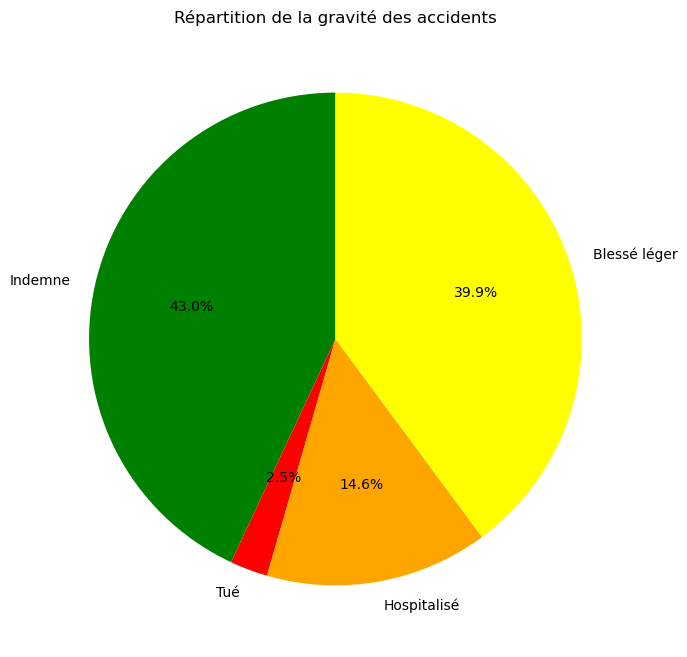

In [99]:
# Distribution de la gravité
plt.figure(figsize=(8, 8))
labels = ["Indemne", "Tué", "Hospitalisé", "Blessé léger"]
colors = ["green", "red", "orange", "yellow"]
sizes = df_final["grav"].value_counts().sort_index()
plt.pie(sizes, labels=labels, colors=colors, autopct="%1.1f%%", startangle=90)
plt.title("Répartition de la gravité des accidents")
plt.show()

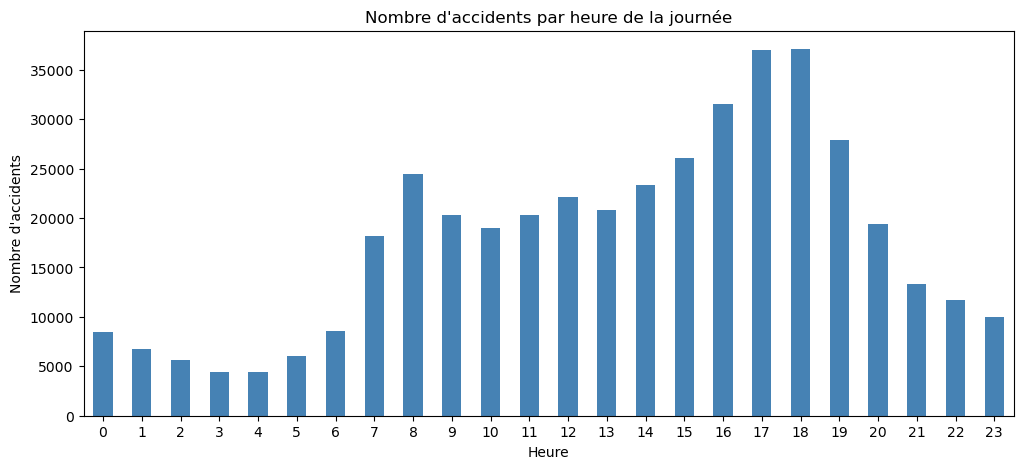

In [100]:
# Accident par heure
plt.figure(figsize=(12, 5))
df_final.groupby("heure").size().plot(kind="bar", color="steelblue")
plt.title("Nombre d'accidents par heure de la journée")
plt.xlabel("Heure")
plt.ylabel("Nombre d'accidents")
plt.xticks(rotation=0)
plt.show()

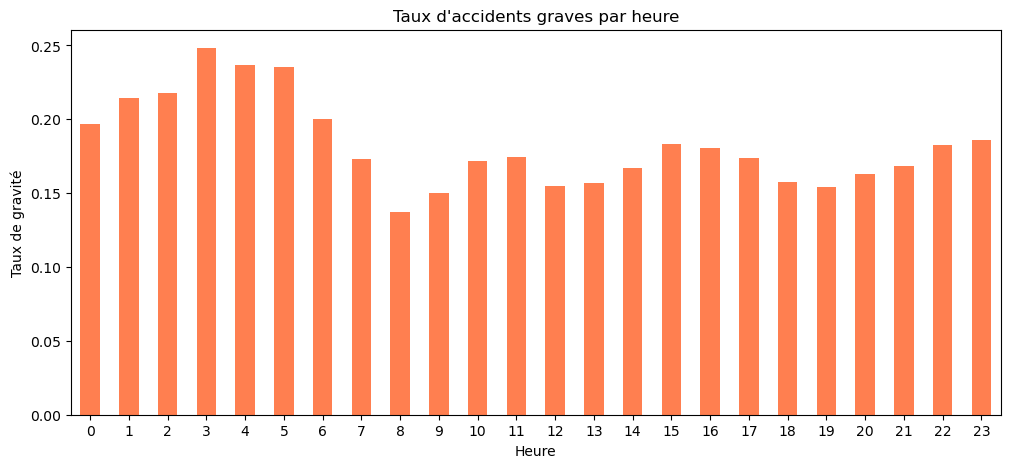

In [101]:
# gravité par heure
plt.figure(figsize=(12, 5))
df_final.groupby("heure")["grav_binaire"].mean().plot(kind="bar", color="coral")
plt.title("Taux d'accidents graves par heure")
plt.xlabel("Heure")
plt.ylabel("Taux de gravité")
plt.xticks(rotation=0)
plt.show()

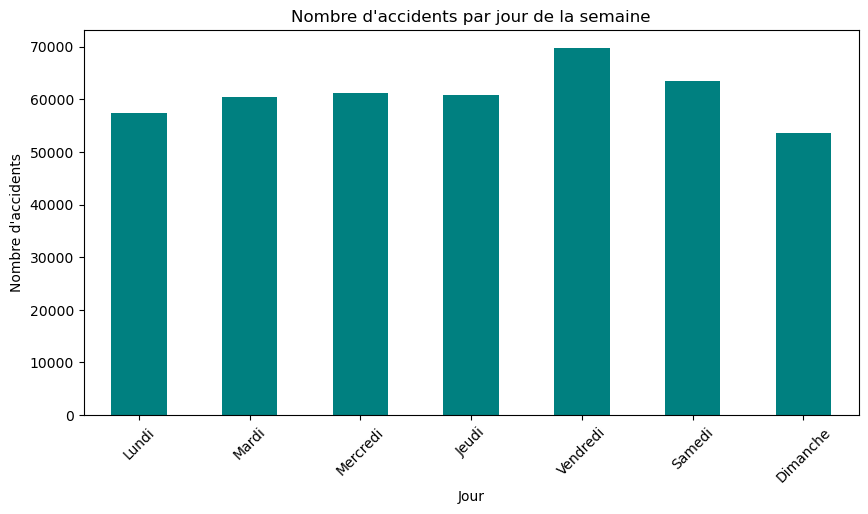

In [102]:
# accident par jour de la semaine
jours = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]
plt.figure(figsize=(10, 5))
df_final["jour_semaine"].value_counts().sort_index().plot(kind="bar", color="teal")
plt.title("Nombre d'accidents par jour de la semaine")
plt.xlabel("Jour")
plt.ylabel("Nombre d'accidents")
plt.xticks(ticks=range(7), labels=jours, rotation=45)
plt.show()

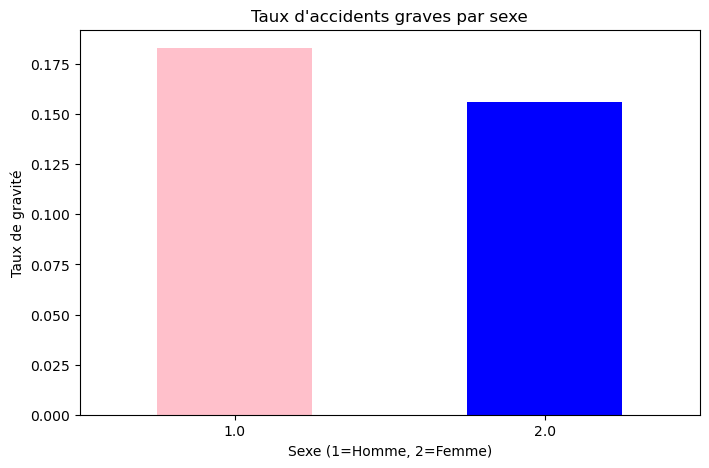

In [103]:
# gravité par sexe
plt.figure(figsize=(8, 5))
df_final.groupby("sexe")["grav_binaire"].mean().plot(kind="bar", color=["pink", "blue"])
plt.title("Taux d'accidents graves par sexe")
plt.xlabel("Sexe (1=Homme, 2=Femme)")
plt.ylabel("Taux de gravité")
plt.xticks(rotation=0)
plt.show()

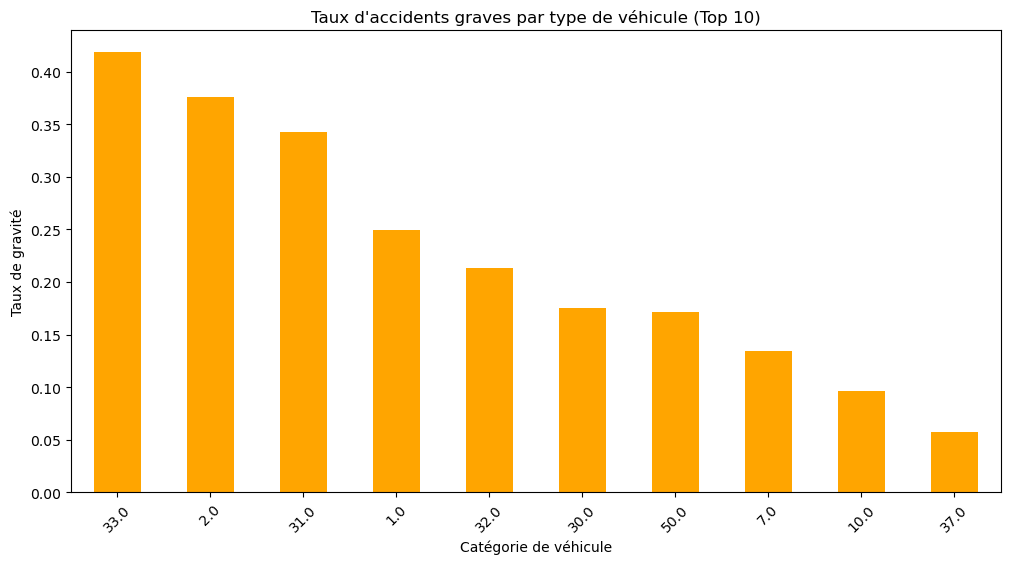

In [104]:
# gravité par type de véhicule (top 10)
plt.figure(figsize=(12, 6))
top_vehicules = df_final["catv"].value_counts().head(10).index
df_top = df_final[df_final["catv"].isin(top_vehicules)]
df_top.groupby("catv")["grav_binaire"].mean().sort_values(ascending=False).plot(
    kind="bar", color="orange"
)
plt.title("Taux d'accidents graves par type de véhicule (Top 10)")
plt.xlabel("Catégorie de véhicule")
plt.ylabel("Taux de gravité")
plt.xticks(rotation=45)
plt.show()

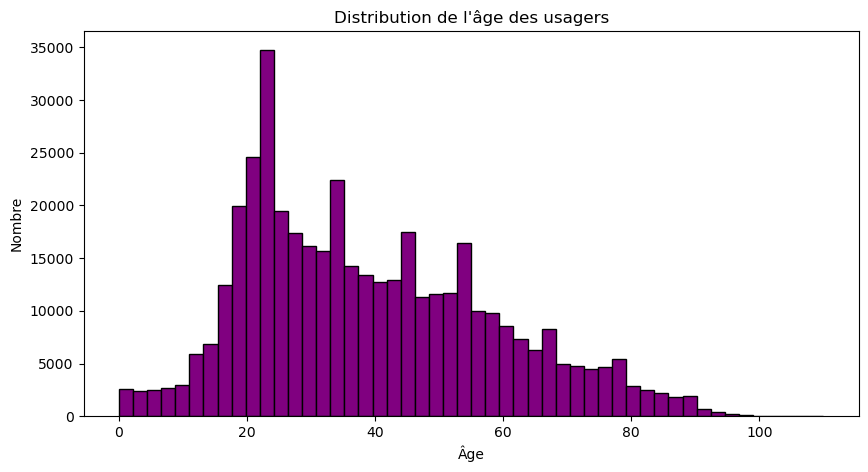

In [105]:
# Distribution par rapport à l'age
plt.figure(figsize=(10, 5))
df_final["age"].dropna().plot(kind="hist", bins=50, color="purple", edgecolor="black")
plt.title("Distribution de l'âge des usagers")
plt.xlabel("Âge")
plt.ylabel("Nombre")
plt.show()

<Figure size 1000x600 with 0 Axes>

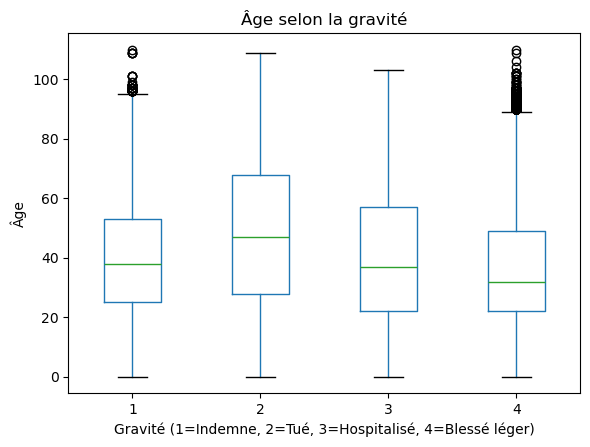

In [106]:
# ou par tranche d'age (boxplot)

plt.figure(figsize=(10, 6))
df_final.boxplot(column="age", by="grav", grid=False)
plt.title("Âge selon la gravité")
plt.suptitle("")
plt.xlabel("Gravité (1=Indemne, 2=Tué, 3=Hospitalisé, 4=Blessé léger)")
plt.ylabel("Âge")
plt.show()

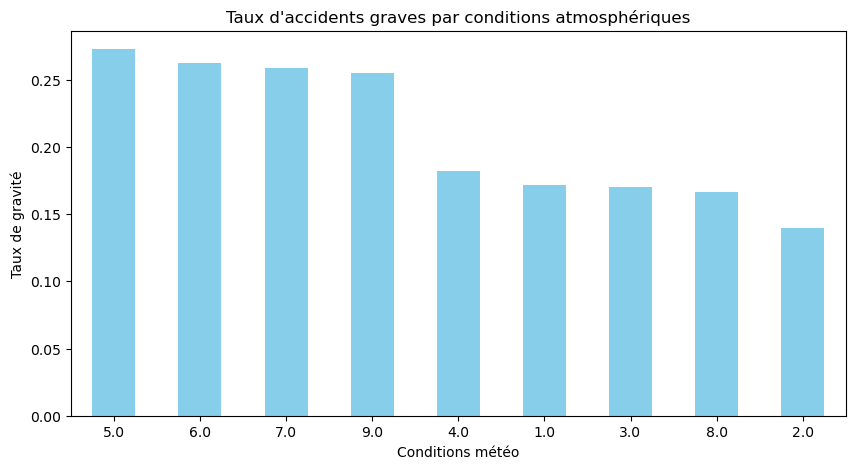

In [107]:
# gravité par rapport à la météo
plt.figure(figsize=(10, 5))
df_final.groupby("atm")["grav_binaire"].mean().sort_values(ascending=False).plot(
    kind="bar", color="skyblue"
)
plt.title("Taux d'accidents graves par conditions atmosphériques")
plt.xlabel("Conditions météo")
plt.ylabel("Taux de gravité")
plt.xticks(rotation=0)
plt.show()

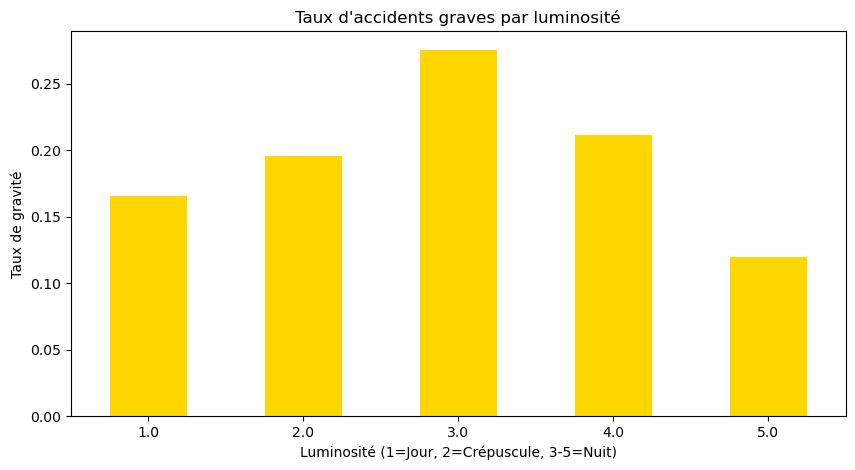

In [108]:
# gravité par rapport à la luminisoité
plt.figure(figsize=(10, 5))
df_final.groupby("lum")["grav_binaire"].mean().plot(kind="bar", color="gold")
plt.title("Taux d'accidents graves par luminosité")
plt.xlabel("Luminosité (1=Jour, 2=Crépuscule, 3-5=Nuit)")
plt.ylabel("Taux de gravité")
plt.xticks(rotation=0)
plt.show()

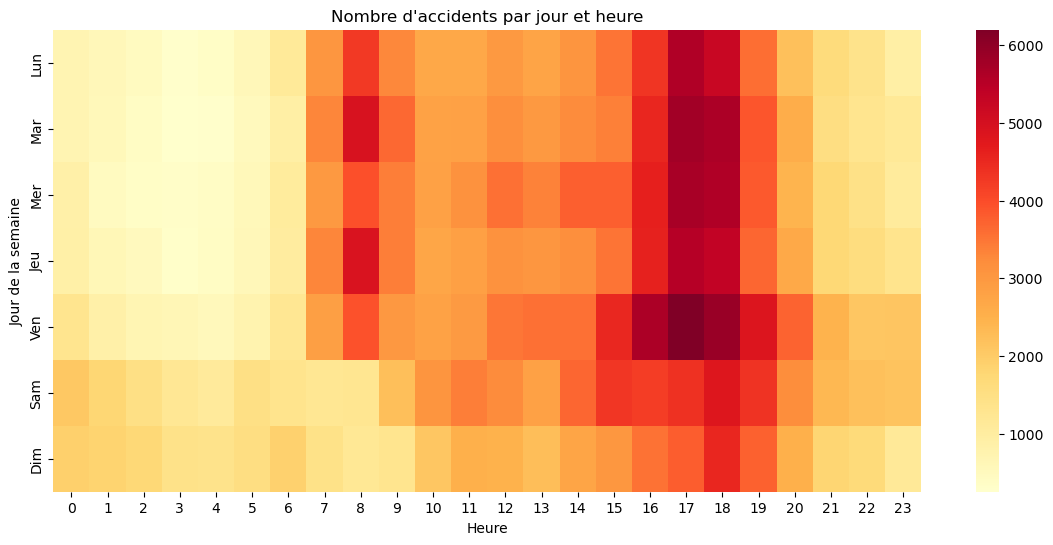

In [109]:
# HEATMAP - Accidents par jour et heure
plt.figure(figsize=(14, 6))
pivot = df_final.groupby(["jour_semaine", "heure"]).size().unstack(fill_value=0)
jours = ["Lun", "Mar", "Mer", "Jeu", "Ven", "Sam", "Dim"]
pivot.index = jours
sns.heatmap(pivot, cmap="YlOrRd", annot=False)
plt.title("Nombre d'accidents par jour et heure")
plt.xlabel("Heure")
plt.ylabel("Jour de la semaine")
plt.show()

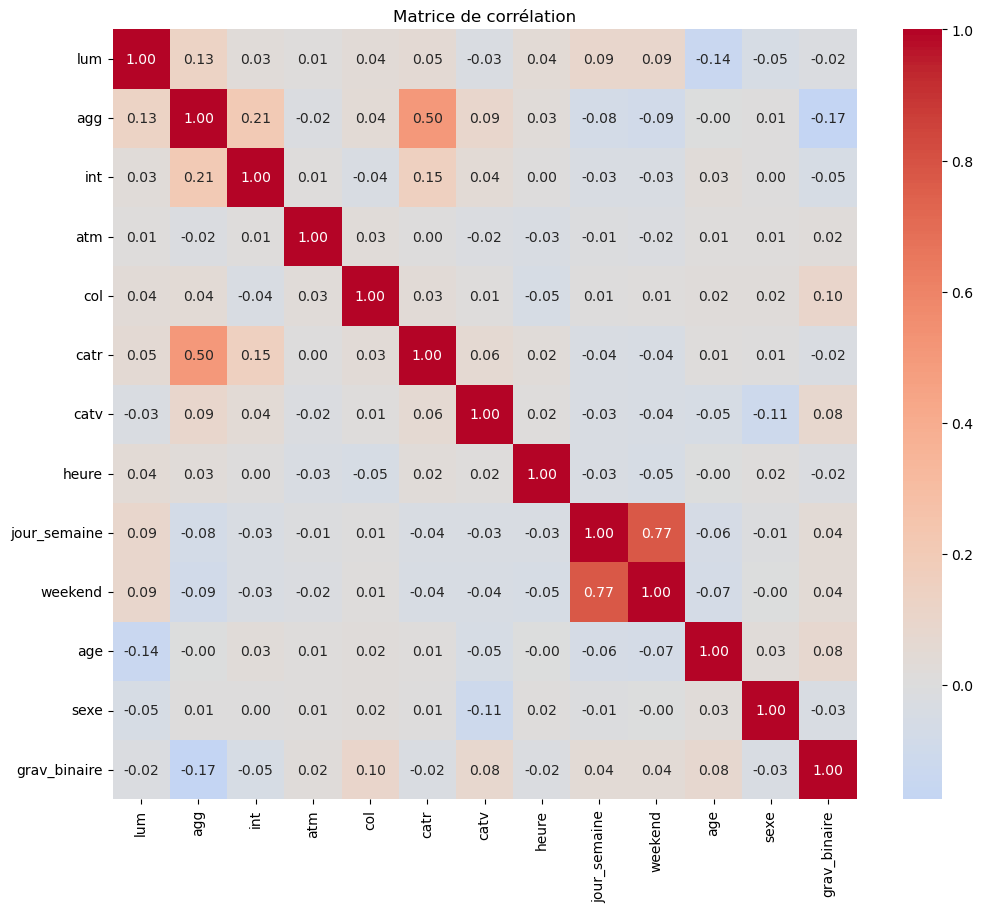

In [110]:
# matrice de correlation
colonnes_corr = [
    "lum",
    "agg",
    "int",
    "atm",
    "col",
    "catr",
    "catv",
    "heure",
    "jour_semaine",
    "weekend",
    "age",
    "sexe",
    "grav_binaire",
]
colonnes_corr = [c for c in colonnes_corr if c in df_final.columns]

plt.figure(figsize=(12, 10))
corr = df_final[colonnes_corr].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, fmt=".2f")
plt.title("Matrice de corrélation")
plt.show()

In [111]:
# Créer une carte centrée sur la France
carte = folium.Map(location=[46.603354, 1.888334], zoom_start=6)

In [112]:
# Prendre un échantillon (sinon trop lourd)
sample = df_final[["lat", "long"]].dropna().sample(5000, random_state=42)

In [113]:
# Ajouter la heatmap
HeatMap(sample.values, radius=8).add_to(carte)

In [114]:
carte

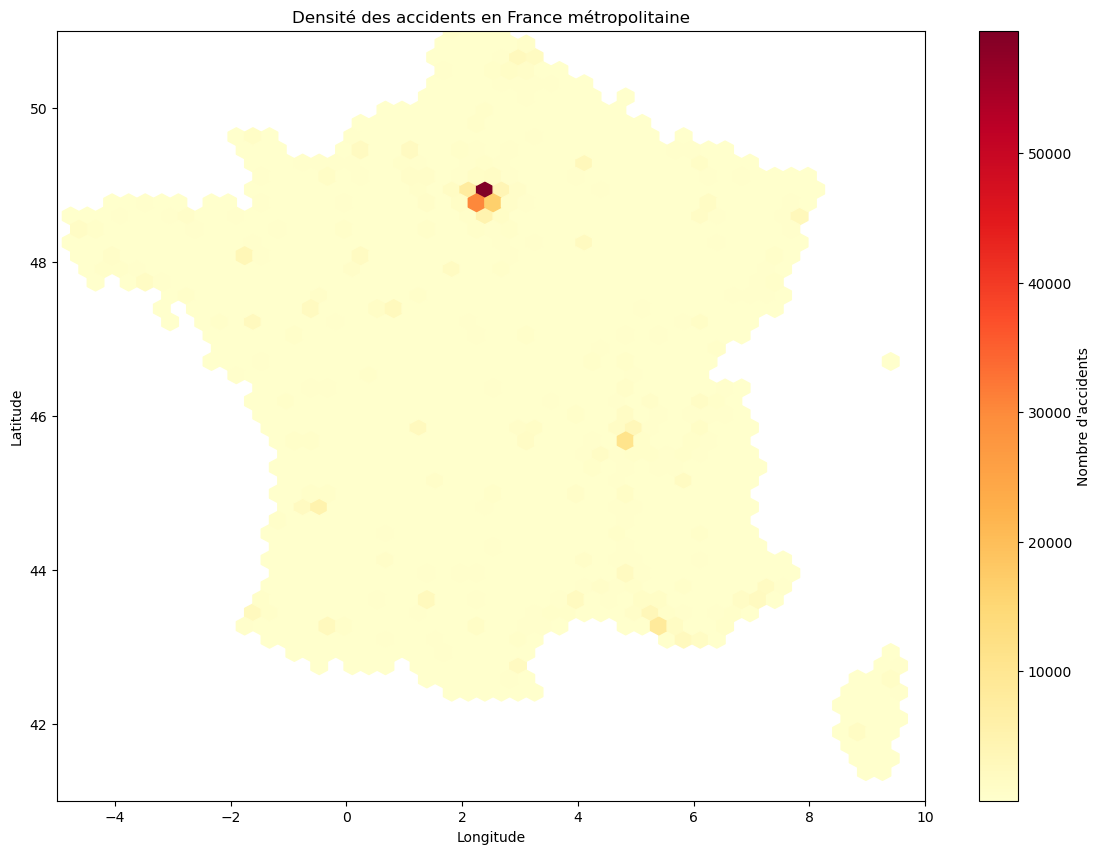

In [115]:
# === CARTE AVEC DENSITÉ ET LÉGENDE ===
plt.figure(figsize=(14, 10))

# Hexbin = montre la densité avec des couleurs
hb = plt.hexbin(df_final["long"], df_final["lat"], gridsize=50, cmap="YlOrRd", mincnt=1)

# légende
cb = plt.colorbar(hb)
cb.set_label("Nombre d'accidents")

plt.title("Densité des accidents en France métropolitaine")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.xlim(-5, 10)
plt.ylim(41, 51)
plt.show()

# =======================
# JOUR 4 : MODELISATION
# =======================

In [116]:
df_final

,Num_Acc,jour,mois,an,hrmn,lum,dep,com,agg,int,...,sexe,an_nais,trajet,secu1,grav_binaire,heure,jour_semaine,weekend,nuit,age
0,2.024000e+11,25,3,2024,07:40,2.0,70,70285,1,1.0,...,1.0,2003.0,2.0,1.0,1,7,0,0,0,21.0
1,2.024000e+11,25,3,2024,07:40,2.0,70,70285,1,1.0,...,1.0,1997.0,4.0,1.0,0,7,0,0,0,27.0
2,2.024000e+11,20,3,2024,15:05,1.0,21,21054,2,3.0,...,2.0,1927.0,5.0,0.0,1,15,2,0,0,97.0
3,2.024000e+11,20,3,2024,15:05,1.0,21,21054,2,3.0,...,1.0,1987.0,4.0,1.0,0,15,2,0,0,37.0
4,2.024000e+11,20,3,2024,15:05,1.0,21,21054,2,3.0,...,2.0,1927.0,5.0,0.0,1,15,2,0,0,97.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
427012,2.022001e+11,1,1,2022,08:40,1.0,81,81099,1,3.0,...,2.0,2002.0,5.0,1.0,0,8,5,1,0,20.0
427013,2.022001e+11,1,1,2022,08:40,1.0,81,81099,1,3.0,...,2.0,2004.0,5.0,1.0,1,8,5,1,0,18.0
427014,2.022001e+11,1,1,2022,08:40,1.0,81,81099,1,3.0,...,2.0,1953.0,5.0,1.0,0,8,5,1,0,69.0
427015,2.022001e+11,1,3,2022,16:55,1.0,41,41018,2,1.0,...,1.0,1992.0,1.0,2.0,1,16,1,0,0,30.0


In [117]:
print(df_final.columns.tolist())

['Num_Acc', 'jour', 'mois', 'an', 'hrmn', 'lum', 'dep', 'com', 'agg', 'int', 'atm', 'col', 'lat', 'long', 'datetime', 'catr', 'circ', 'nbv', 'vosp', 'prof', 'plan', 'lartpc', 'larrout', 'surf', 'infra', 'situ', 'vma', 'id_vehicule', 'senc', 'catv', 'obs', 'obsm', 'choc', 'manv', 'motor', 'place', 'catu', 'grav', 'sexe', 'an_nais', 'trajet', 'secu1', 'grav_binaire', 'heure', 'jour_semaine', 'weekend', 'nuit', 'age']


In [118]:
df_final.isnull().sum()

Num_Acc              0
jour                 0
mois                 0
an                   0
hrmn                 0
lum                  4
dep                  0
com                  0
agg                  0
int                 27
atm                  6
col                159
lat                  0
long                 0
datetime             0
catr                 0
circ             25911
nbv                  0
vosp             17386
prof               453
plan               434
lartpc          426435
larrout              0
surf               546
infra             5024
situ               521
vma              19230
id_vehicule          0
senc               622
catv                 8
obs                154
obsm               127
choc               198
manv               111
motor              673
place                3
catu                 0
grav                 0
sexe              8392
an_nais           8981
trajet            8822
secu1             7773
grav_binaire         0
heure      

Ces NaN sont acceptables (moins de 10%). On va les gérer lors de la préparation des données pour le ML.

In [119]:
# Créer une colonne terre_plein (1 = présent, 0 = absent)
df_final["terre_plein"] = df_final["lartpc"].notna().astype(int)

print(df_final["terre_plein"].value_counts())

terre_plein
0    426435
1       243
Name: count, dtype: int64


In [120]:
# Choisir les features pour le modele

features = [
    "lum",
    "agg",
    "int",
    "atm",
    "col",
    "catr",
    "catv",
    "heure",
    "jour_semaine",
    "weekend",
    "sexe",
    "age",
    "secu1",
    "terre_plein",
]

In [121]:
# Crée X (features) & Y (target)

X = df_final[features].copy()
y = df_final["grav_binaire"].copy()

In [122]:
print(f"Avant nettoyage : {X.shape[0]} lignes")

Avant nettoyage : 426678 lignes


In [123]:
# supprimer les lignes avec des NaN

X = X.dropna()
y = y.loc[X.index]

In [124]:
print(f"Après nettoyage : {X.shape[0]} lignes")
print(f"Features : {X.shape[1]}")

Après nettoyage : 416628 lignes
Features : 14


In [125]:
X.isnull().sum()

lum             0
agg             0
int             0
atm             0
col             0
catr            0
catv            0
heure           0
jour_semaine    0
weekend         0
sexe            0
age             0
secu1           0
terre_plein     0
dtype: int64

In [126]:
# separer en train/test 70/30
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# separer temp en validation (15%) et test (15%)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,  # 50% de 30% = 15%
    random_state=42,
    stratify=y_temp,
)

print(f"Train : {X_train.shape[0]} lignes ({X_train.shape[0] / len(X) * 100:.0f}%)")
print(f"Validation : {X_val.shape[0]} lignes ({X_val.shape[0] / len(X) * 100:.0f}%)")
print(f"Test : {X_test.shape[0]} lignes ({X_test.shape[0] / len(X) * 100:.0f}%)")

Train : 291639 lignes (70%)
Validation : 62494 lignes (15%)
Test : 62495 lignes (15%)


On va faire de la standardisation pour les modeles qui en ont besoin à savoir KNN & regression logistique. 

In [127]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

In [128]:
# Modèles à tester
modeles = {
    "Random Forest": (
        RandomForestClassifier(
            n_estimators=100, random_state=42, class_weight="balanced"
        ),
        False,
    ),
    "Decision Tree": (
        DecisionTreeClassifier(random_state=42, class_weight="balanced"),
        False,
    ),
    "Gradient Boosting": (
        GradientBoostingClassifier(n_estimators=100, random_state=42),
        False,
    ),
    "Régression Logistique": (
        LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced"),
        True,
    ),
    "KNN": (KNeighborsClassifier(n_neighbors=5), True),
}

# False = pas besoin de standardisation (arbres)
# True = besoin de standardisation (KNN, régression logistique)

resultats = []

for nom, (modele, besoin_scale) in modeles.items():
    print(f"Entraînement de {nom}...")

    # Choisir les données (scaled ou non)
    if besoin_scale:
        X_tr, X_va = X_train_scaled, X_val_scaled
    else:
        X_tr, X_va = X_train, X_val

    # Entraîner
    modele.fit(X_tr, y_train)

    # Prédire
    y_pred = modele.predict(X_va)

    # Scores
    acc = accuracy_score(y_val, y_pred)
    f1 = f1_score(y_val, y_pred)

    resultats.append(
        {"Modèle": nom, "Accuracy": round(acc, 3), "F1-Score": round(f1, 3)}
    )

Entraînement de Random Forest...
Entraînement de Decision Tree...
Entraînement de Gradient Boosting...
Entraînement de Régression Logistique...
Entraînement de KNN...


In [129]:
df_resultats = pd.DataFrame(resultats)
df_resultats = df_resultats.sort_values("F1-Score", ascending=False)
print(df_resultats.to_string(index=False))

               Modèle  Accuracy  F1-Score
        Random Forest     0.864     0.542
        Decision Tree     0.824     0.501
                  KNN     0.828     0.386
Régression Logistique     0.640     0.375
    Gradient Boosting     0.844     0.353


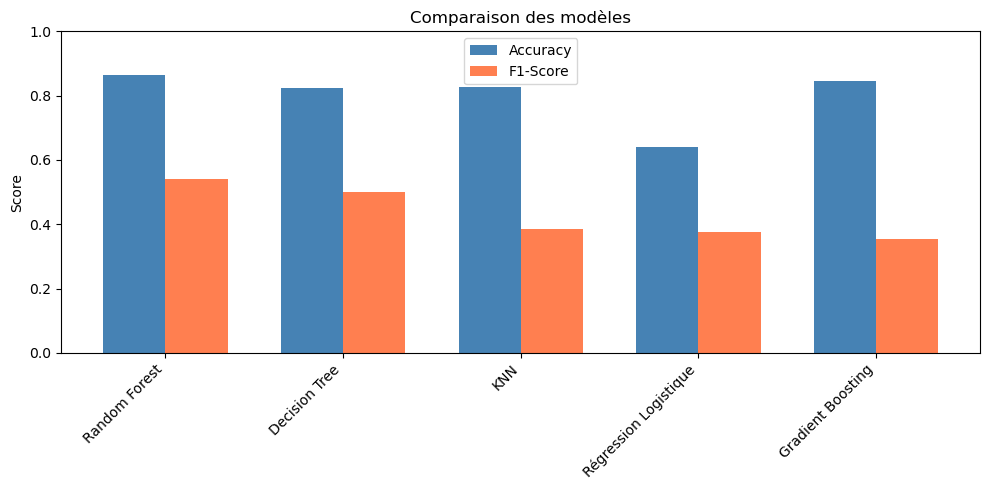

In [130]:
fig, ax = plt.subplots(figsize=(10, 5))

x = range(len(df_resultats))
width = 0.35

ax.bar(
    [i - width / 2 for i in x],
    df_resultats["Accuracy"],
    width,
    label="Accuracy",
    color="steelblue",
)
ax.bar(
    [i + width / 2 for i in x],
    df_resultats["F1-Score"],
    width,
    label="F1-Score",
    color="coral",
)

ax.set_ylabel("Score")
ax.set_title("Comparaison des modèles")
ax.set_xticks(x)
ax.set_xticklabels(df_resultats["Modèle"], rotation=45, ha="right")
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

In [131]:
# Comparer Train vs Validation pour chaque modèle (pr detecter de l'overfitting)
resultats_overfit = []

for nom, (modele, besoin_scale) in modeles.items():
    if besoin_scale:
        X_tr, X_va = X_train_scaled, X_val_scaled
    else:
        X_tr, X_va = X_train, X_val

    y_pred_tr = modele.predict(X_tr)
    y_pred_va = modele.predict(X_va)

    resultats_overfit.append(
        {
            "Modèle": nom,
            "Train": round(accuracy_score(y_train, y_pred_tr), 3),
            "Validation": round(accuracy_score(y_val, y_pred_va), 3),
        }
    )

df_overfit = pd.DataFrame(resultats_overfit)
print(df_overfit.to_string(index=False))

               Modèle  Train  Validation
        Random Forest  0.993       0.864
        Decision Tree  0.993       0.824
    Gradient Boosting  0.846       0.844
Régression Logistique  0.639       0.640
                  KNN  0.874       0.828


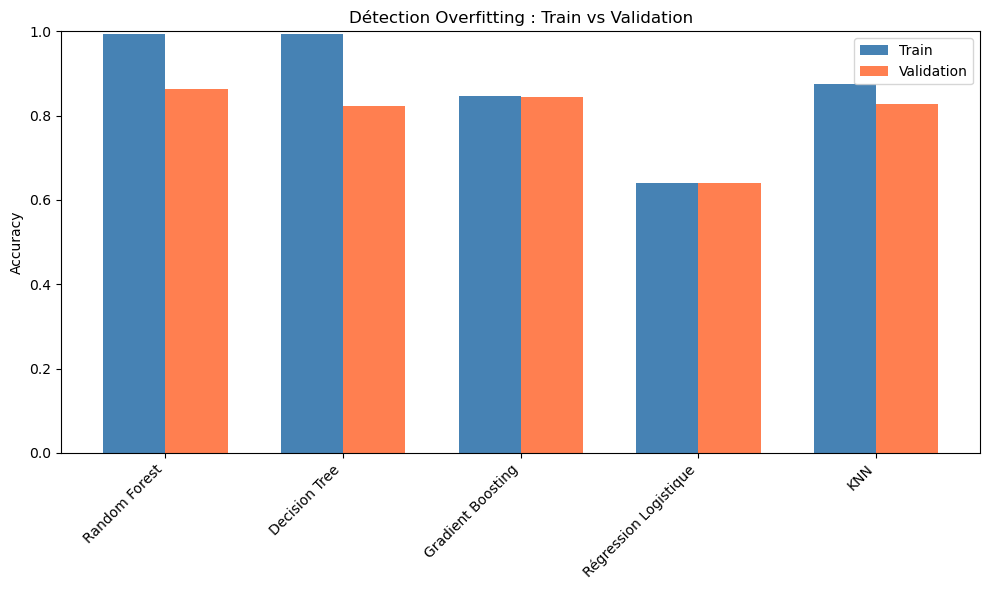

In [132]:
# graphique overfitting
fig, ax = plt.subplots(figsize=(10, 6))

x = range(len(df_overfit))
width = 0.35

ax.bar(
    [i - width / 2 for i in x],
    df_overfit["Train"],
    width,
    label="Train",
    color="steelblue",
)
ax.bar(
    [i + width / 2 for i in x],
    df_overfit["Validation"],
    width,
    label="Validation",
    color="coral",
)

ax.set_ylabel("Accuracy")
ax.set_title("Détection Overfitting : Train vs Validation")
ax.set_xticks(x)
ax.set_xticklabels(df_overfit["Modèle"], rotation=45, ha="right")
ax.legend()
ax.set_ylim(0, 1)

plt.tight_layout()
plt.show()

on voit qu'il y a de l'overfitting pour random forest et decision tree par contre il n'y en a pas pour gradient boosting, regression logistique et KNN. 

On va choisir gradient boosting il a un bon score ET n'a pas d'overfitting.. 

In [135]:
# Calculer les poids
sample_weights = compute_sample_weight("balanced", y_train)

# Entraîner Gradient Boosting avec les poids
gb_balanced = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb_balanced.fit(X_train, y_train, sample_weight=sample_weights)

# Prédire
y_pred_balanced = gb_balanced.predict(X_test)

print("=== Gradient Boosting avec gestion du déséquilibre ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_balanced):.3f}")
print(f"F1-Score : {f1_score(y_test, y_pred_balanced):.3f}")

=== Gradient Boosting avec gestion du déséquilibre ===
Accuracy : 0.721
F1-Score : 0.493


In [136]:
# Utiliser Gradient Boosting comme meilleur modèle
meilleur_modele = modeles["Gradient Boosting"][0]
meilleur_nom = "Gradient Boosting"

y_pred_test = meilleur_modele.predict(X_test)

print(f"Meilleur modèle : {meilleur_nom}")
print(
    classification_report(y_test, y_pred_balanced, target_names=["Pas grave", "Grave"])
)

Meilleur modèle : Gradient Boosting
              precision    recall  f1-score   support

   Pas grave       0.94      0.71      0.81     51576
       Grave       0.36      0.78      0.49     10919

    accuracy                           0.72     62495
   macro avg       0.65      0.74      0.65     62495
weighted avg       0.84      0.72      0.75     62495



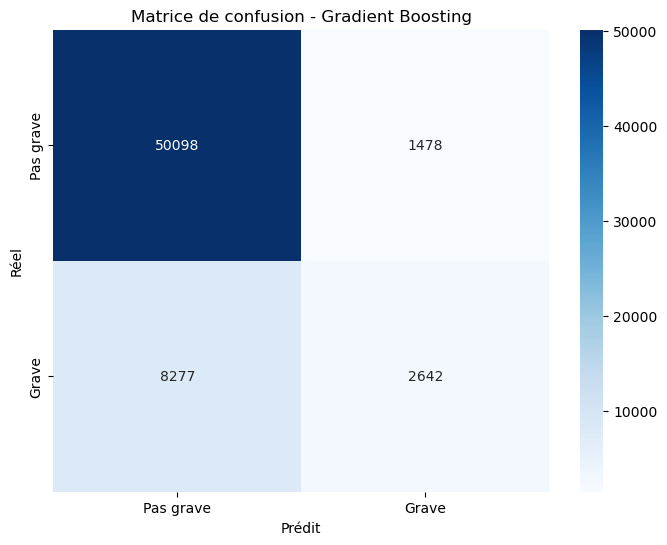

In [137]:
# matrice de confusion

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pas grave", "Grave"],
    yticklabels=["Pas grave", "Grave"],
)
plt.title(f"Matrice de confusion - {meilleur_nom}")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

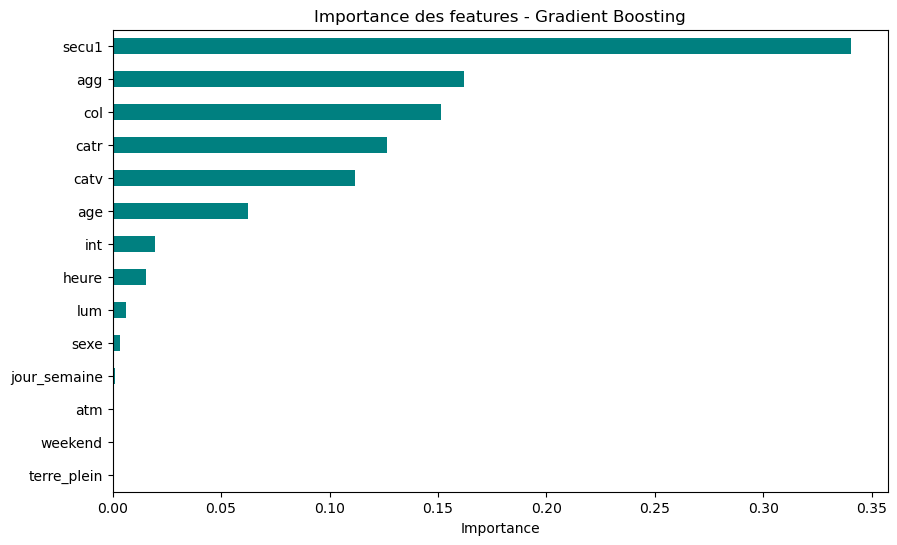


Top 5 features :
secu1    0.340232
agg      0.161893
col      0.151286
catr     0.126451
catv     0.111746
dtype: float64


In [138]:
# Importance des features
plt.figure(figsize=(10, 6))
importance = pd.Series(
    meilleur_modele.feature_importances_, index=features
).sort_values()
importance.plot(kind="barh", color="teal")
plt.title(f"Importance des features - {meilleur_nom}")
plt.xlabel("Importance")
plt.show()

print("\nTop 5 features :")
print(importance.sort_values(ascending=False).head())

On va ajuster les poids parce qu'il prédit 8277 accidents GRAVES commes pas grave et c'est dangereux. C'est surement à cause d'un déséquilibre des classes vu qu'on bcp + de pas grave que de grave dans les données. 

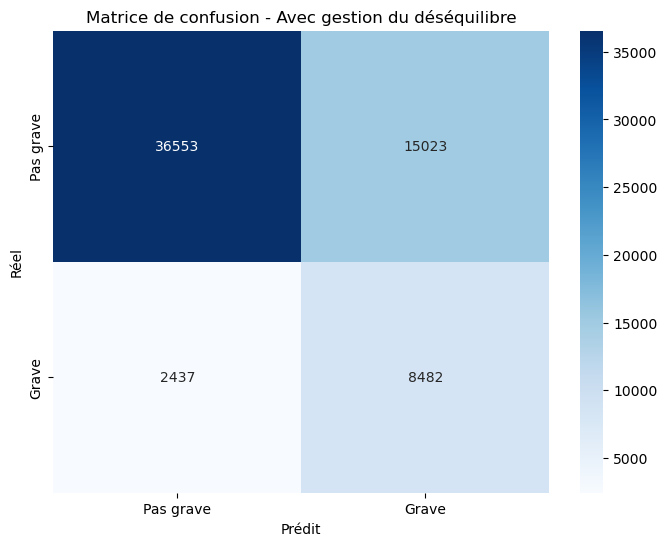


=== Comparaison ===
AVANT - Recall (Grave) : 0.242
APRÈS - Recall (Grave) : 0.777


In [141]:
# Matrice de confusion APRÈS équilibrage
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_pred_balanced)
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Pas grave", "Grave"],
    yticklabels=["Pas grave", "Grave"],
)
plt.title("Matrice de confusion - Avec gestion du déséquilibre")
plt.xlabel("Prédit")
plt.ylabel("Réel")
plt.show()

# Comparaison
print("\n=== Comparaison ===")
print(f"AVANT - Recall (Grave) : {recall_score(y_test, y_pred_test):.3f}")
print(f"APRÈS - Recall (Grave) : {recall_score(y_test, y_pred_balanced):.3f}")

In [142]:
import sklearn

print(sklearn.__version__)

1.5.1


In [143]:
# Sauvegarder le modèle avec gestion du déséquilibre (le meilleur)
joblib.dump(gb_balanced, "modele_final.pkl")
joblib.dump(scaler, "scaler.pkl")
joblib.dump(features, "features.pkl")

print("Modèle sauvegardé : modele_final.pkl")
print("Scaler sauvegardé : scaler.pkl")
print("Features sauvegardées : features.pkl")

Modèle sauvegardé : modele_final.pkl
Scaler sauvegardé : scaler.pkl
Features sauvegardées : features.pkl


In [144]:
# résumé final
print("=" * 50)
print("RÉSUMÉ DU MODÈLE FINAL")
print("=" * 50)
print("Modèle : Gradient Boosting (avec gestion du déséquilibre)")
print("Recall (Grave) : 0.777 (77.7%)")
print("Accuracy : 0.721 (72.1%)")
print("F1-Score : 0.493")
print("=" * 50)

RÉSUMÉ DU MODÈLE FINAL
Modèle : Gradient Boosting (avec gestion du déséquilibre)
Recall (Grave) : 0.777 (77.7%)
Accuracy : 0.721 (72.1%)
F1-Score : 0.493


# ================================
# JOUR 5 : API & FRONT-END
# ================================